# 64: KmerSeek HP SCOPe40 p-value Benchmark vs TEA/FoldSeek

Evaluate KmerSeek HP k-mers (k=15–50) on the SCOPe40 all-vs-all benchmark using
Poisson p-values (raw, Bonferroni, BH, BY) as the ranking metric.

**Goals:**
1. Survey precision/recall across all k-sizes and p-value correction methods
2. Convert best kmerseek results to `.rocx` format and compare sensitivity curves vs TEA & FoldSeek
3. Test whether kmerseek detects homologs at low sequence identity (<30%) using the SCOPe processed-at-threshold datasets
4. BCL2/Ced9 spotlight: which k-size / correction best recovers this distant pair?

**Data sources:**
- Nextflow benchmark output: `~/data/scope/results-scope-pvalue-benchmark/`
  - `scope_benchmark_summary.tsv` – aggregated precision/recall across all k-sizes
  - `scope_eval.hp.k{k}.tsv` – per-pair evaluation with SCOP labels + p-values
  - `scope_eval.hp.k{k}.pr_data.tsv` – sampled PR curves per level/method
- TEA / FoldSeek baselines: `data/tea_scope40_rocx_files/`
- SCOPe40 sequence-identity thresholds: `data/SCOPe/processed_at_th/`


## 1. Imports & Paths

In [31]:
import sys
from pathlib import Path

import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.integrate import trapezoid

sys.path.append(str(Path.cwd()))
from scope_kmerseek_utils import (
    load_rocx_file,
    plot_sensitivity_from_rocx,
    compute_auc,
)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.dpi'] = 120

# ── Paths ──────────────────────────────────────────────────────────────────
BENCH_DIR  = Path('/Users/olga/data/scope/results-scope-pvalue-benchmark')
TEA_DIR    = Path('/Users/olga/code/2024-kmerseek-analysis/data/tea_scope40_rocx_files')
THRESH_DIR = Path('/Users/olga/code/2024-kmerseek-analysis/data/SCOPe/processed_at_th')

KMIN, KMAX = 15, 50
KSIZES = list(range(KMIN, KMAX + 1))

# P-value correction methods
METHODS = ['raw', 'bonferroni', 'bh', 'by']
METHOD_COLS = {'raw': 'poisson_pvalue', 'bonferroni': 'bonferroni', 'bh': 'bh', 'by': 'by'}
METHOD_COLORS = {'raw': 'grey', 'bonferroni': 'steelblue', 'bh': 'tomato', 'by': 'goldenrod'}
METHOD_LABELS = {'raw': 'Raw p-value', 'bonferroni': 'Bonferroni', 'bh': 'BH (FDR)', 'by': 'BY'}

SCOP_LEVELS = ['class', 'fold', 'superfamily', 'family']

print('Paths configured.')
print(f'Benchmark dir exists: {BENCH_DIR.exists()}')
print(f'TEA dir exists: {TEA_DIR.exists()}')
print(f'Threshold dir exists: {THRESH_DIR.exists()}')

Paths configured.
Benchmark dir exists: True
TEA dir exists: True
Threshold dir exists: True


## 2. Load Summary Data

In [32]:
summary = pl.read_csv(BENCH_DIR / 'scope_benchmark_summary.tsv.gz', separator='\t')
print(f'Summary shape: {summary.shape}')
print(f'K-sizes present: {sorted(summary["ksize"].to_list())}')
summary.head(5)

Summary shape: (36, 50)
K-sizes present: [15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]


ksize,n_pairs,class_raw_rejected,class_raw_precision,class_raw_recall,class_bonferroni_rejected,class_bonferroni_precision,class_bonferroni_recall,class_bh_rejected,class_bh_precision,class_bh_recall,class_by_rejected,class_by_precision,class_by_recall,fold_raw_rejected,fold_raw_precision,fold_raw_recall,fold_bonferroni_rejected,fold_bonferroni_precision,fold_bonferroni_recall,fold_bh_rejected,fold_bh_precision,fold_bh_recall,fold_by_rejected,fold_by_precision,fold_by_recall,superfamily_raw_rejected,superfamily_raw_precision,superfamily_raw_recall,superfamily_bonferroni_rejected,superfamily_bonferroni_precision,superfamily_bonferroni_recall,superfamily_bh_rejected,superfamily_bh_precision,superfamily_bh_recall,superfamily_by_rejected,superfamily_by_precision,superfamily_by_recall,family_raw_rejected,family_raw_precision,family_raw_recall,family_bonferroni_rejected,family_bonferroni_precision,family_bonferroni_recall,family_bh_rejected,family_bh_precision,family_bh_recall,family_by_rejected,family_by_precision,family_by_recall
i64,i64,i64,f64,f64,i64,f64,f64,i64,f64,f64,i64,f64,f64,i64,f64,f64,i64,f64,f64,i64,f64,f64,i64,f64,f64,i64,f64,f64,i64,f64,f64,i64,f64,f64,i64,f64,f64,i64,f64,f64,i64,f64,f64,i64,f64,f64,i64,f64,f64
15,43598650,21265436,0.2642,0.5036,458339,0.2774,0.0114,15776586,0.2654,0.3753,5808502,0.2695,0.1403,21265436,0.0129,0.5412,458339,0.0243,0.0219,15776586,0.0135,0.421,5808502,0.0155,0.1773,21265436,0.0073,0.5642,458339,0.0181,0.03,15776586,0.0077,0.4417,5808502,0.0094,0.1976,21265436,0.0026,0.5985,458339,0.0087,0.0429,15776586,0.0028,0.4817,5808502,0.0038,0.2347
16,22023742,15785872,0.2651,0.7427,411227,0.2804,0.0205,13758458,0.2652,0.6474,5182672,0.2675,0.246,15785872,0.0131,0.783,411227,0.0243,0.0379,13758458,0.0133,0.6931,5182672,0.015,0.2934,15785872,0.0075,0.8044,411227,0.0184,0.0513,13758458,0.0077,0.7142,5182672,0.0092,0.3221,15785872,0.0028,0.8373,411227,0.009,0.0712,13758458,0.0028,0.7434,5182672,0.0037,0.3662
17,10872329,9297502,0.2665,0.8924,397799,0.2804,0.0402,9220932,0.2666,0.8853,4469182,0.2694,0.4337,9297502,0.013,0.9013,397799,0.0236,0.07,9220932,0.013,0.8954,4469182,0.015,0.4998,9297502,0.0079,0.9398,397799,0.0179,0.0914,9220932,0.0079,0.9341,4469182,0.0094,0.5371,9297502,0.0029,0.9444,397799,0.0086,0.1189,9220932,0.0029,0.9417,4469182,0.0038,0.591
18,5368116,4801201,0.2627,0.9174,374285,0.2824,0.0769,4702045,0.2644,0.9042,3253429,0.2744,0.6492,4801201,0.0136,0.9295,374285,0.0239,0.1276,4702045,0.0137,0.9157,3253429,0.0158,0.7326,4801201,0.0085,0.9565,374285,0.0182,0.1605,4702045,0.0086,0.9472,3253429,0.0101,0.7716,4801201,0.0033,0.9573,374285,0.0087,0.1961,4702045,0.0034,0.9509,3253429,0.0042,0.8149
19,2665851,2658899,0.258,0.9977,319930,0.2856,0.1329,2658686,0.258,0.9977,2068498,0.2696,0.8112,2658899,0.0141,0.9984,319930,0.0247,0.2102,2658686,0.0141,0.9983,2068498,0.0155,0.8533,2658899,0.009,0.9989,319930,0.0191,0.2551,2658686,0.009,0.9988,2068498,0.0103,0.8894,2658899,0.0037,0.9991,319930,0.0092,0.2956,2658686,0.0037,0.9991,2068498,0.0044,0.9154


## 3. Best K-size: Recall at Family & Superfamily Levels

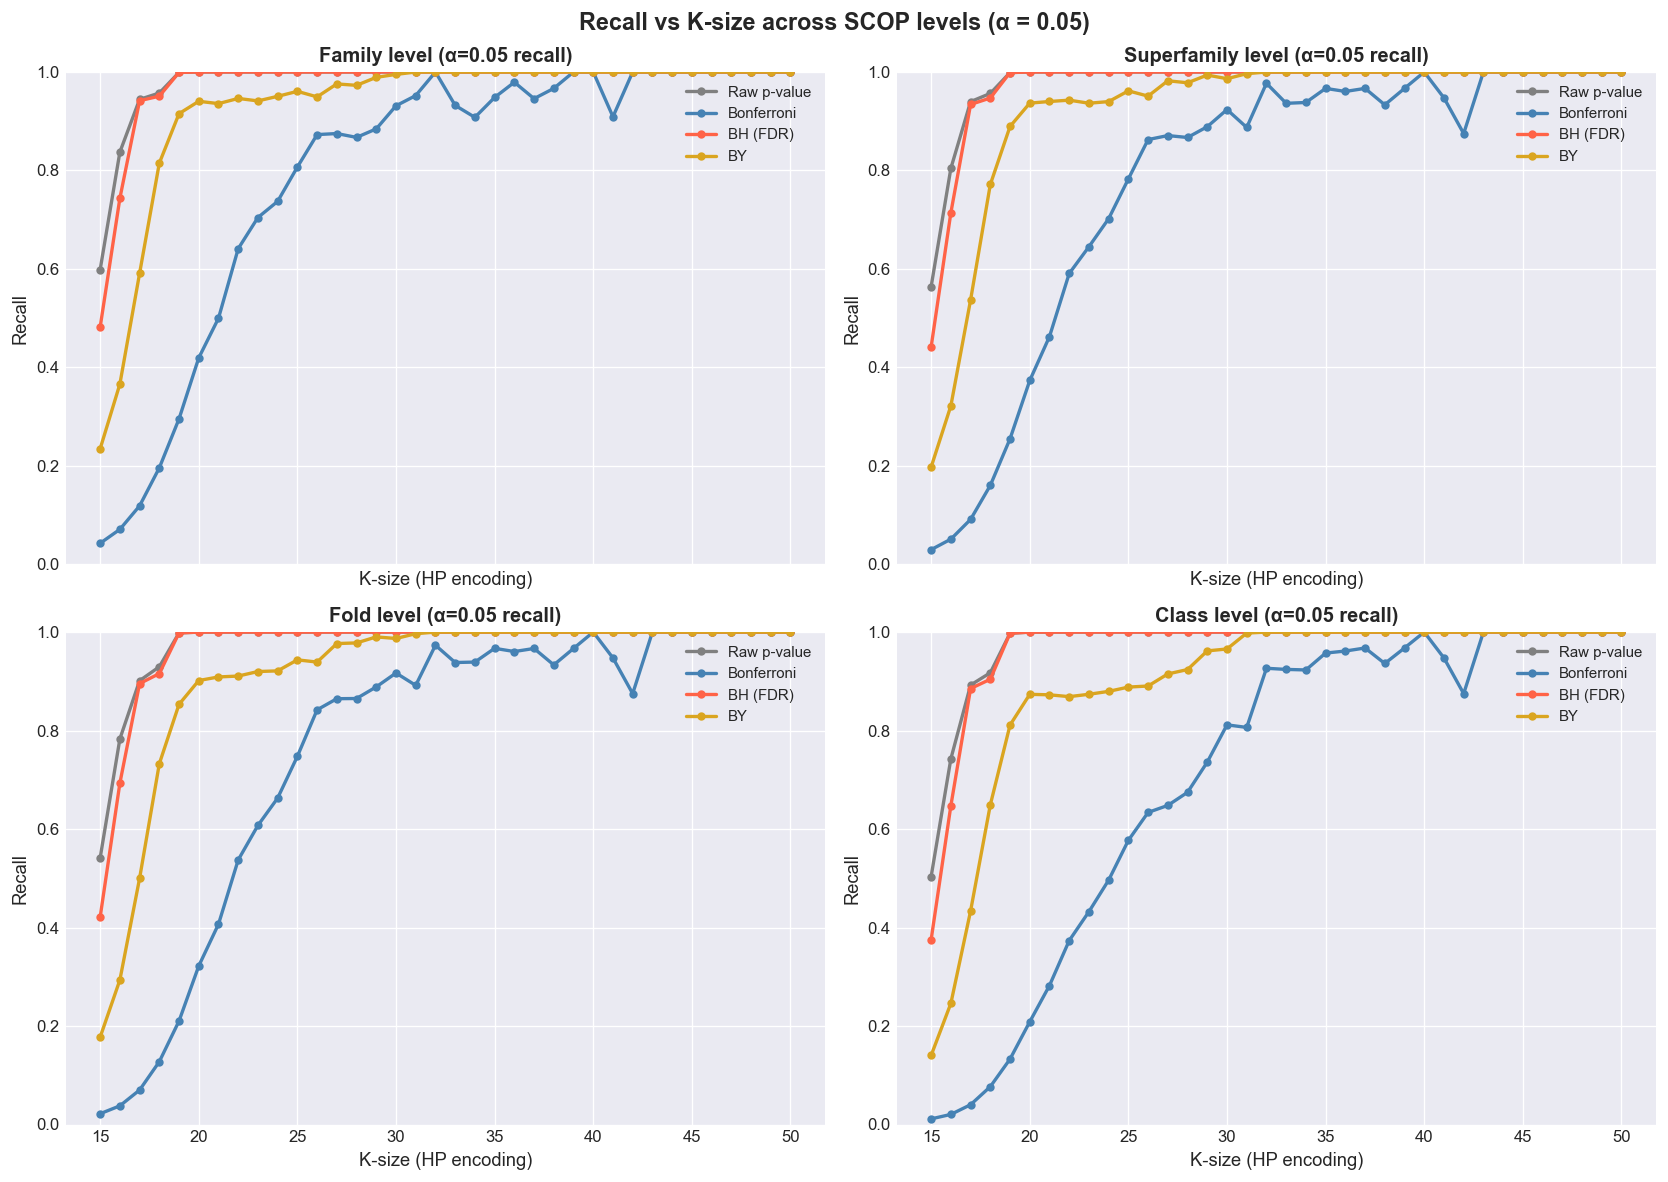

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

levels_to_plot = [
    ('family',      'Family'),
    ('superfamily', 'Superfamily'),
    ('fold',        'Fold'),
    ('class',       'Class'),
]

for ax, (lvl, lvl_label) in zip(axes.flatten(), levels_to_plot):
    for mth in METHODS:
        col = f'{lvl}_{mth}_recall'
        if col not in summary.columns:
            continue
        ax.plot(
            summary['ksize'].to_numpy(),
            summary[col].to_numpy(),
            'o-', label=METHOD_LABELS[mth],
            color=METHOD_COLORS[mth], linewidth=2, markersize=4,
        )
    ax.set_title(f'{lvl_label} level (α=0.05 recall)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Recall', fontsize=11)
    ax.set_xlabel('K-size (HP encoding)', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1)

plt.suptitle('Recall vs K-size across SCOP levels (α = 0.05)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scope_pvalue_recall_vs_ksize.pdf', bbox_inches='tight')
plt.show()

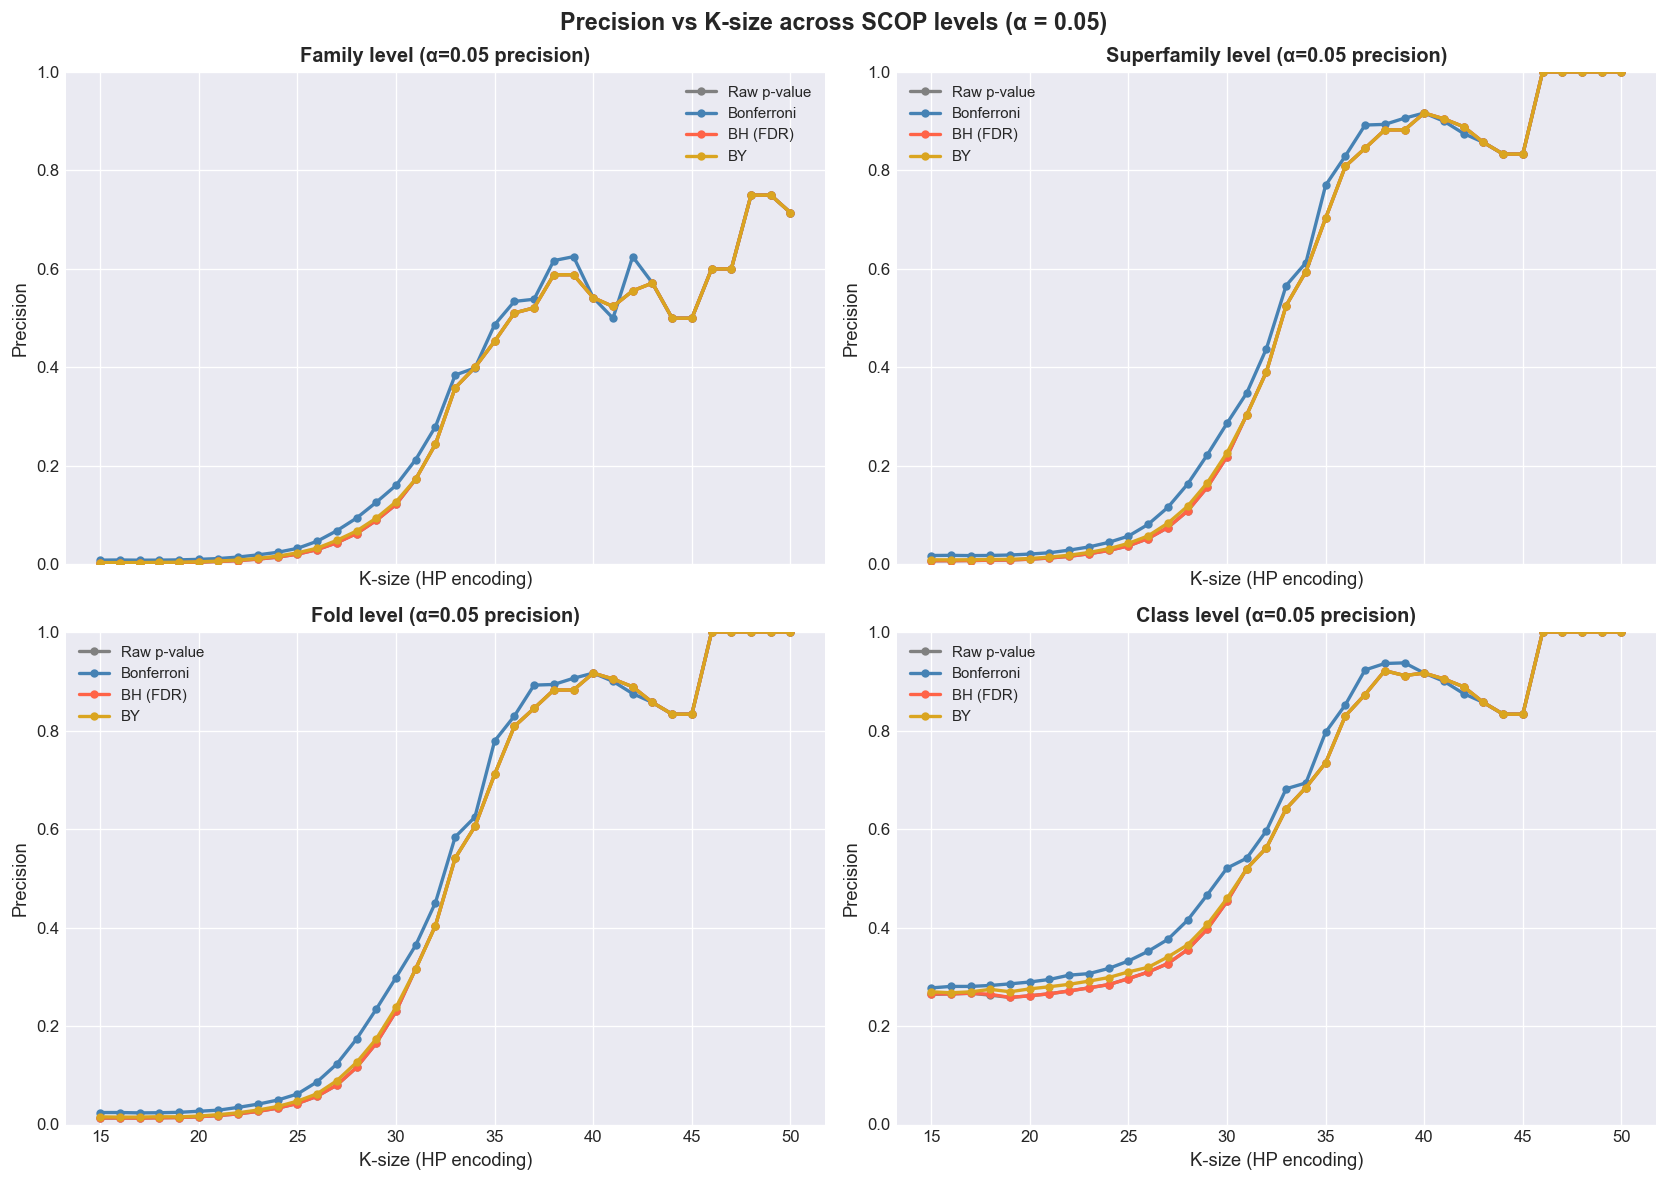

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

for ax, (lvl, lvl_label) in zip(axes.flatten(), levels_to_plot):
    for mth in METHODS:
        col = f'{lvl}_{mth}_precision'
        if col not in summary.columns:
            continue
        ax.plot(
            summary['ksize'].to_numpy(),
            summary[col].to_numpy(),
            'o-', label=METHOD_LABELS[mth],
            color=METHOD_COLORS[mth], linewidth=2, markersize=4,
        )
    ax.set_title(f'{lvl_label} level (α=0.05 precision)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_xlabel('K-size (HP encoding)', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1)

plt.suptitle('Precision vs K-size across SCOP levels (α = 0.05)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('scope_pvalue_precision_vs_ksize.pdf', bbox_inches='tight')
plt.show()

In [35]:
# Find best k-size by BH recall at family level (or superfamily if family recall is 0)
for target_level in ['family', 'superfamily']:
    col = f'{target_level}_bh_recall'
    if col in summary.columns:
        best_row = summary.sort(col, descending=True).row(0, named=True)
        best_k = best_row['ksize']
        best_recall = best_row[col]
        best_precision = best_row[f'{target_level}_bh_precision']
        print(f'{target_level.capitalize()} level (BH): best k={best_k}  recall={best_recall:.4f}  precision={best_precision:.4f}')

# Show full table for family + superfamily, sorted by BH recall
cols = (['ksize', 'n_pairs'] +
        [f'family_{m}_recall' for m in METHODS] +
        [f'superfamily_{m}_recall' for m in METHODS])
cols_present = [c for c in cols if c in summary.columns]
print('\nBH recall across k-sizes (family + superfamily):')
print(summary.select(cols_present).sort('family_bh_recall', descending=True).head(10))

Family level (BH): best k=20  recall=1.0000  precision=0.0046
Superfamily level (BH): best k=20  recall=1.0000  precision=0.0106

BH recall across k-sizes (family + superfamily):
shape: (10, 10)
┌───────┬─────────┬────────────┬────────────┬───┬────────────┬────────────┬────────────┬───────────┐
│ ksize ┆ n_pairs ┆ family_raw ┆ family_bon ┆ … ┆ superfamil ┆ superfamil ┆ superfamil ┆ superfami │
│ ---   ┆ ---     ┆ _recall    ┆ ferroni_re ┆   ┆ y_raw_reca ┆ y_bonferro ┆ y_bh_recal ┆ ly_by_rec │
│ i64   ┆ i64     ┆ ---        ┆ call       ┆   ┆ ll         ┆ ni_recall  ┆ l          ┆ all       │
│       ┆         ┆ f64        ┆ ---        ┆   ┆ ---        ┆ ---        ┆ ---        ┆ ---       │
│       ┆         ┆            ┆ f64        ┆   ┆ f64        ┆ f64        ┆ f64        ┆ f64       │
╞═══════╪═════════╪════════════╪════════════╪═══╪════════════╪════════════╪════════════╪═══════════╡
│ 20    ┆ 1330710 ┆ 1.0        ┆ 0.4195     ┆ … ┆ 1.0        ┆ 0.3735     ┆ 1.0        ┆ 0.9368   

## 4. Precision-Recall Curves for Best K-sizes

Load the sampled PR curve data and plot for selected k-sizes.

In [36]:
# Load PR data for a few key k-sizes
best_k_family = summary.sort('family_bh_recall', descending=True)['ksize'][0]
best_k_sfam   = summary.sort('superfamily_bh_recall', descending=True)['ksize'][0]

# Load the k=24 as a mid-range reference if not already selected
key_ksizes = sorted(set([best_k_family, best_k_sfam, 24]))
print(f'Loading PR data for k-sizes: {key_ksizes}')

pr_dfs = {}
for k in key_ksizes:
    pr_file = BENCH_DIR / f'scope_eval.hp.k{k}.pr_data.tsv'
    if pr_file.exists():
        pr_dfs[k] = pl.read_csv(pr_file, separator='\t')
        print(f'  k={k}: {len(pr_dfs[k]):,} rows')
    else:
        print(f'  k={k}: file not found')

Loading PR data for k-sizes: [20, 24]
  k=20: file not found
  k=24: file not found


/var/folders/rl/81r400y52z38l8_kwn4g1xdc0000gn/T/ipykernel_28644/151391477.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)


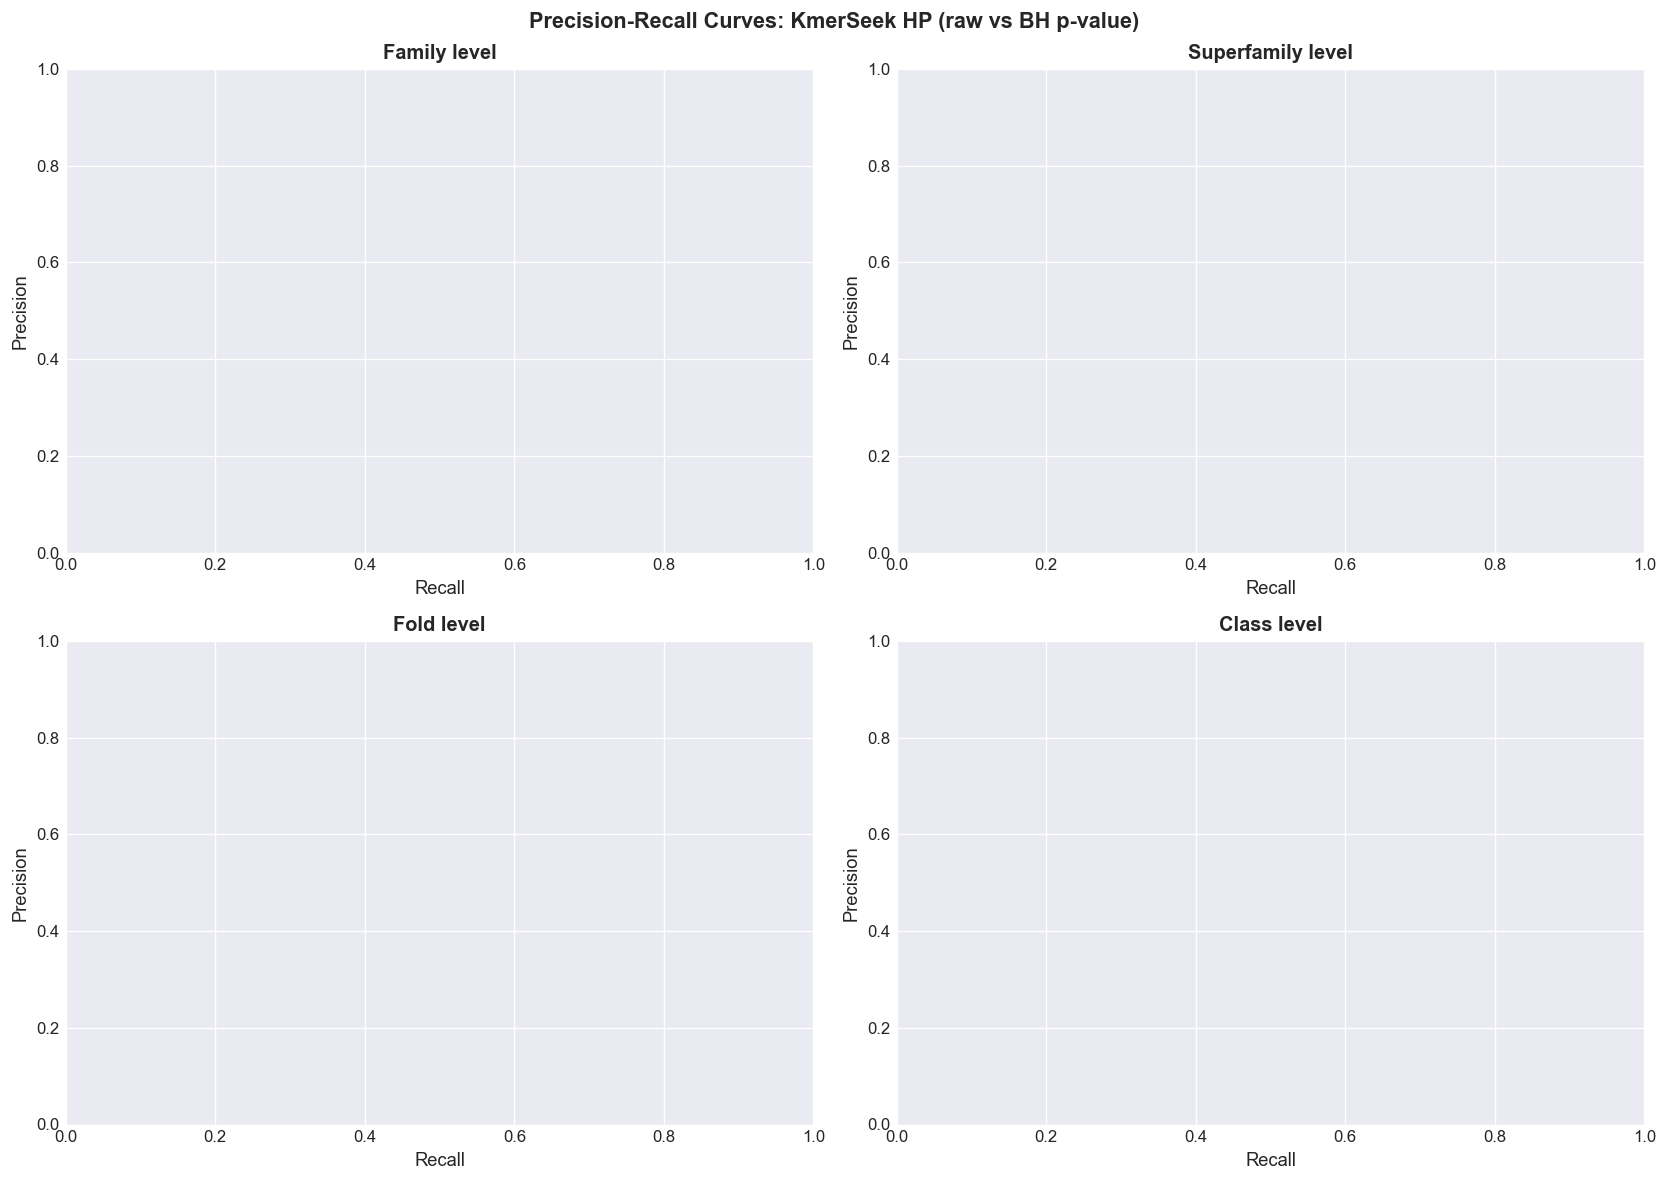

In [37]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

linestyles = ['-', '--', '-.']

for ax, (lvl, lvl_label) in zip(axes.flatten(), levels_to_plot):
    for i, (k, pr_df) in enumerate(pr_dfs.items()):
        lvl_df = pr_df.filter(pl.col('level') == lvl)
        for mth in ['raw', 'bh']:
            md = lvl_df.filter(pl.col('method') == mth).sort('recall')
            if len(md) == 0:
                continue
            label = f'k={k} {METHOD_LABELS[mth]}'
            ax.plot(
                md['recall'].to_numpy(), md['precision'].to_numpy(),
                linestyle=linestyles[i % len(linestyles)],
                color=METHOD_COLORS[mth],
                linewidth=1.8, alpha=0.8,
                label=label,
            )
    ax.set_title(f'{lvl_label} level', fontsize=12, fontweight='bold')
    ax.set_xlabel('Recall', fontsize=11)
    ax.set_ylabel('Precision', fontsize=11)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

plt.suptitle('Precision-Recall Curves: KmerSeek HP (raw vs BH p-value)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scope_pvalue_pr_curves.pdf', bbox_inches='tight')
plt.show()

## 5. Convert Eval TSV to ROCX Format

Convert the per-pair eval TSV (which already has SCOP labels and p-values) to
the `.rocx` format used by TEA/FoldSeek, so we can directly compare sensitivity
curves.

In [38]:
def eval_tsv_to_rocx(
    df: pl.DataFrame,
    score_col: str = 'poisson_pvalue',
    ascending: bool = True,  # lower p-value = better
) -> pl.DataFrame:
    """
    Convert kmerseek scope_eval TSV (already deduplicated to best pair per
    query-target) into TEA .rocx format.
    """
    df = df.filter(pl.col('query_domain') != pl.col('target_domain'))

    queries = df['query_domain'].unique().to_list()
    results = []

    for query in queries:
        qdf = (
            df.filter(pl.col('query_domain') == query)
              .sort(score_col, descending=not ascending)
        )
        if len(qdf) == 0:
            continue

        row = {
            'NAME': query,
            'SCOP': qdf['q_scop_id'][0],
        }

        for level_abbr, same_col in [
            ('FAM',  'same_family'),
            ('SFAM', 'same_superfamily'),
            ('FOLD', 'same_fold'),
        ]:
            same_vals = qdf[same_col].to_list()
            n_same = sum(same_vals)

            if n_same == 0:
                row[level_abbr] = 0.0
                row[f'{level_abbr}CNT'] = 0
            else:
                first_fp = next((i for i, v in enumerate(same_vals) if not v), None)
                if first_fp is None:
                    sensitivity = 1.0
                elif first_fp == 0:
                    sensitivity = 0.0
                else:
                    sensitivity = min(first_fp / n_same, 1.0)
                row[level_abbr] = sensitivity
                row[f'{level_abbr}CNT'] = n_same

        row['FP'] = 0 if qdf['same_family'][0] else 1
        results.append(row)

    return pl.DataFrame(results)


def load_eval(k: int, bench_dir: Path = BENCH_DIR) -> pl.DataFrame:
    """Load scope_eval for ksize k: prefers .parquet, falls back to .tsv."""
    pq  = bench_dir / f'scope_eval.hp.k{k}.parquet'
    tsv = bench_dir / f'scope_eval.hp.k{k}.tsv'
    if pq.exists():
        return pl.read_parquet(pq)
    elif tsv.exists():
        print(f'  (parquet not found, reading TSV for k={k})')
        return pl.read_csv(tsv, separator='\t')
    else:
        raise FileNotFoundError(f'No eval file found for k={k}')


print('eval_tsv_to_rocx() and load_eval() defined.')


eval_tsv_to_rocx() and load_eval() defined.


In [39]:
# Convert eval TSV/parquet to rocx for key k-sizes, all 4 correction methods
kmerseek_rocx_all = {}  # k -> {method -> rocx DataFrame}
kmerseek_rocx = {}      # k -> rocx (BH, for backward compat)

for k in key_ksizes:
    print(f'Loading k={k} eval...')
    eval_df = load_eval(k)
    print(f'  {len(eval_df):,} pairs')

    kmerseek_rocx_all[k] = {}
    for mth in METHODS:
        rocx = eval_tsv_to_rocx(eval_df, score_col=METHOD_COLS[mth], ascending=True)
        kmerseek_rocx_all[k][mth] = rocx

    kmerseek_rocx[k] = kmerseek_rocx_all[k]['bh']
    print(f'  ROCX queries (BH): {len(kmerseek_rocx[k]):,}')

print('\nDone.')


Loading k=20 eval...
  1,330,710 pairs
  ROCX queries (BH): 15,170
Loading k=24 eval...
  84,715 pairs
  ROCX queries (BH): 14,689

Done.


## 6. Load TEA & FoldSeek Baselines

In [40]:
foldseek = load_rocx_file(TEA_DIR / 'foldseek.rocx')
tea_all  = pl.read_csv(TEA_DIR / 'tea_all.rocx', separator=',')

print(f'FoldSeek: {len(foldseek):,} queries, columns: {foldseek.columns}')
print(f'TEA all:  {len(tea_all):,} queries, columns: {tea_all.columns}')
foldseek.head(3)

FoldSeek: 5,713 queries, columns: ['NAME', 'SCOP', 'FAM', 'SFAM', 'FOLD', 'FP', 'FAMCNT', 'SFAMCNT', 'FOLDCNT']
TEA all:  5,737 queries, columns: ['NAME', 'SCOP', 'FAM', 'SFAM', 'FOLD', 'FP', 'FAMCNT', 'SFAMCNT', 'FOLDCNT']


NAME,SCOP,FAM,SFAM,FOLD,FP,FAMCNT,SFAMCNT,FOLDCNT
str,str,f64,f64,f64,i64,i64,i64,i64
"""d1b9ha_""","""c.67.1.4""",1.0,0.992366,0.0,1,13,143,145
"""d3ctaa2""","""b.43.5.2""",1.0,0.4,0.0,1,2,6,55
"""d2ckxa1""","""a.4.1.3""",0.357143,0.0505051,0.0,1,15,113,425


In [41]:
# ── Common query set for fair cross-method comparison ────────────────────
# FoldSeek's query set = SCOPe40 sequences with ≥1 family member in the DB
# (the TEA-paper reference set).  We restrict all methods to this set so the
# x-axis (fraction of queries) is comparable.  KmerSeek queries not found by
# FoldSeek get sensitivity=0 (they are genuine misses, not excluded).

def rocx_restrict(rocx_df: pl.DataFrame, ref_queries: set) -> pl.DataFrame:
    """Restrict ROCX to ref_queries; missing queries get sensitivity=0."""
    present = rocx_df.filter(pl.col('NAME').is_in(ref_queries))
    missing_ids = sorted(ref_queries - set(present['NAME'].to_list()))
    if not missing_ids:
        return present
    n = len(missing_ids)
    zero_rows = pl.DataFrame({
        'NAME':    missing_ids,
        'SCOP':    [''] * n,
        'FAM':     [0.0] * n,
        'SFAM':    [0.0] * n,
        'FOLD':    [0.0] * n,
        'FP':      [1] * n,
        'FAMCNT':  [0] * n,
        'SFAMCNT': [0] * n,
        'FOLDCNT': [0] * n,
    })
    return pl.concat([present, zero_rows])

ref_queries = set(foldseek['NAME'].to_list())
print(f'Reference query set (FoldSeek): {len(ref_queries):,} queries')


Reference query set (FoldSeek): 5,713 queries


In [42]:
# ── Common query set for fair cross-method comparison ────────────────────
# FoldSeek's query set = SCOPe40 sequences with ≥1 family member in the DB
# (the TEA-paper reference set).  We restrict all methods to this set so the
# x-axis (fraction of queries) is comparable.  KmerSeek queries not found by
# FoldSeek get sensitivity=0 (they are genuine misses, not excluded).

def rocx_restrict(rocx_df: pl.DataFrame, ref_queries: set) -> pl.DataFrame:
    """Restrict ROCX to ref_queries; missing queries get sensitivity=0."""
    present = rocx_df.filter(pl.col('NAME').is_in(ref_queries))
    missing_ids = sorted(ref_queries - set(present['NAME'].to_list()))
    if not missing_ids:
        return present
    n = len(missing_ids)
    zero_rows = pl.DataFrame({
        'NAME':    missing_ids,
        'SCOP':    [''] * n,
        'FAM':     [0.0] * n,
        'SFAM':    [0.0] * n,
        'FOLD':    [0.0] * n,
        'FP':      [1] * n,
        'FAMCNT':  [0] * n,
        'SFAMCNT': [0] * n,
        'FOLDCNT': [0] * n,
    })
    return pl.concat([present, zero_rows.select(present.columns)])

ref_queries = set(foldseek['NAME'].to_list())
print(f'Reference query set (FoldSeek): {len(ref_queries):,} queries')


Reference query set (FoldSeek): 5,713 queries


  k=20 raw         : 5,713 queries  5,568 zero-FAM  SFAM AUC=0.0264
  k=20 bonferroni  : 5,713 queries  5,568 zero-FAM  SFAM AUC=0.0264
  k=20 bh          : 5,713 queries  5,568 zero-FAM  SFAM AUC=0.0264
  k=20 by          : 5,713 queries  5,568 zero-FAM  SFAM AUC=0.0264
  k=24 raw         : 5,713 queries  5,556 zero-FAM  SFAM AUC=0.0451
  k=24 bonferroni  : 5,713 queries  5,556 zero-FAM  SFAM AUC=0.0446
  k=24 bh          : 5,713 queries  5,556 zero-FAM  SFAM AUC=0.0451
  k=24 by          : 5,713 queries  5,556 zero-FAM  SFAM AUC=0.0451


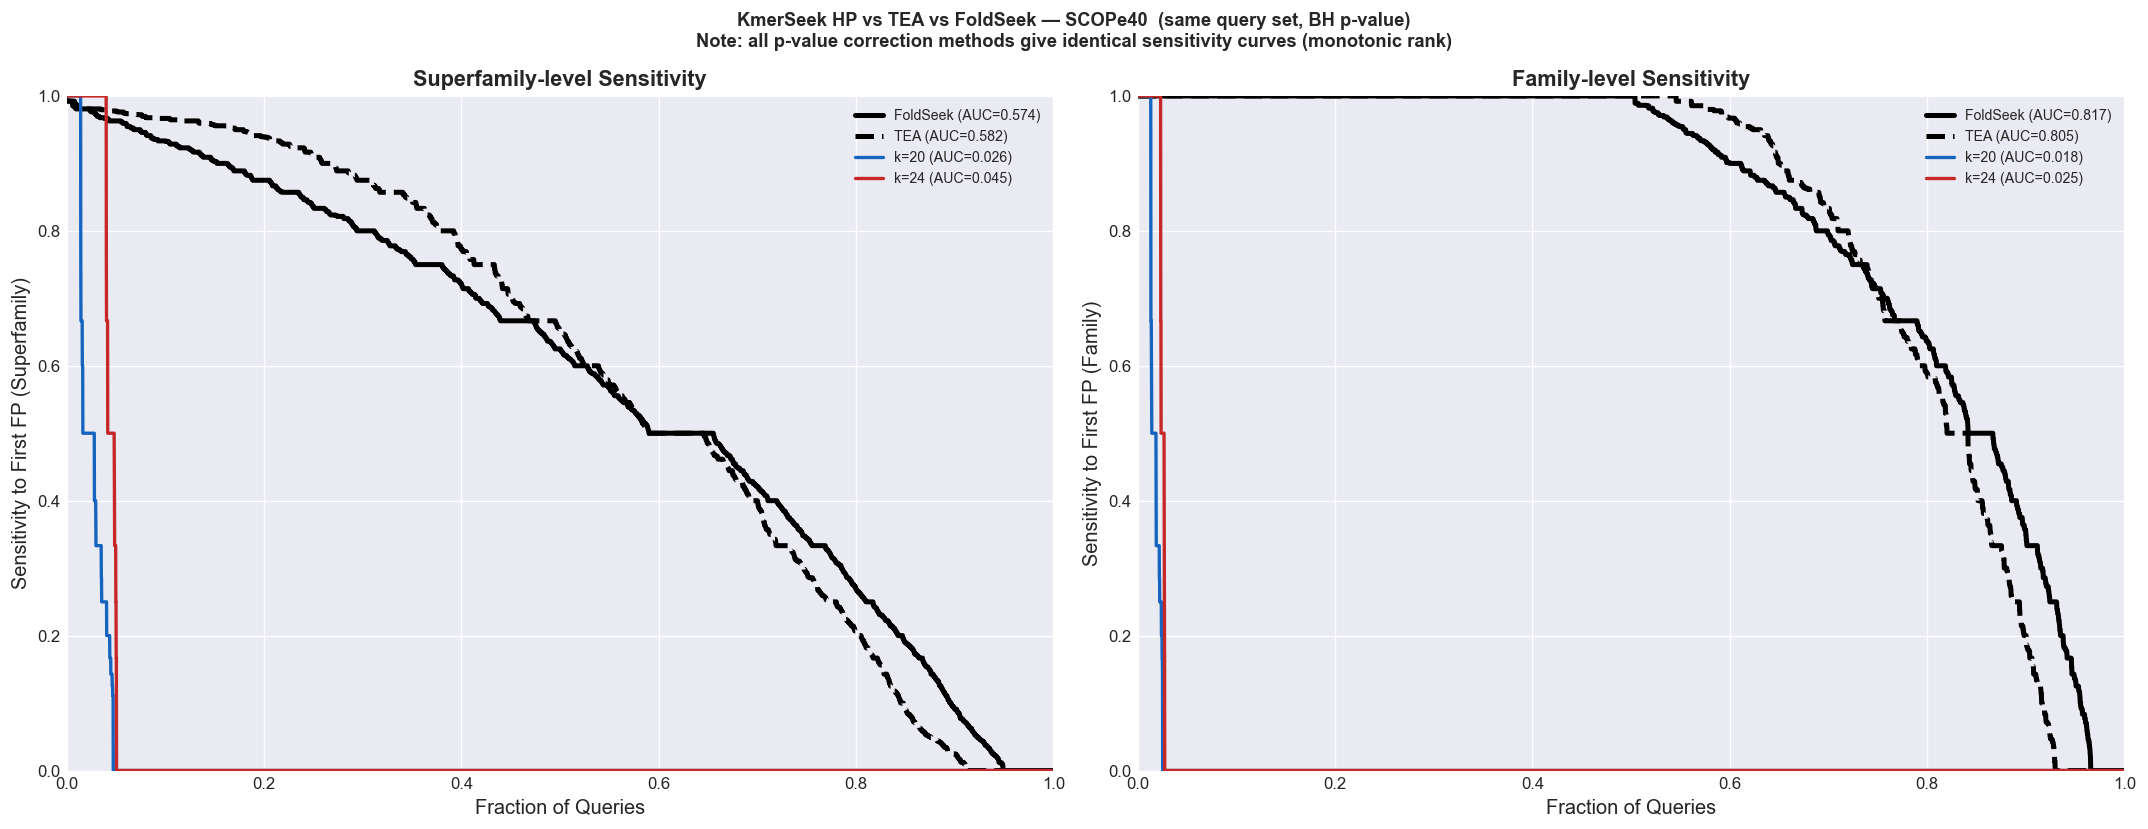

In [43]:
def sensitivity_stats(rocx_df, level_col='SFAM'):
    frac, sens = plot_sensitivity_from_rocx(rocx_df, level_col=level_col)
    auc = compute_auc(frac, sens)
    return frac, sens, auc


# ── Color scheme ──────────────────────────────────────────────────────────
# Color encodes k-size; only 1 correction method per k-size on this plot
# (all correction methods give identical sensitivity curves because they are
# monotonic transformations of the same raw p-value — ranking is unchanged).
KSIZE_COLORS = [
    '#1565C0',  # deep blue
    '#C62828',  # deep red
    '#2E7D32',  # deep green
    '#6A1B9A',  # deep purple
    '#E65100',  # deep orange
    '#00695C',  # dark teal
]

# Restrict KmerSeek ROCX to the reference query set (ref_queries defined above)
foldseek_r = rocx_restrict(foldseek,  ref_queries)
tea_r       = rocx_restrict(tea_all,   ref_queries)

kmerseek_rocx_r = {}  # k -> method -> restricted rocx
for k in sorted(kmerseek_rocx_all.keys()):
    kmerseek_rocx_r[k] = {}
    for mth in METHODS:
        r = rocx_restrict(kmerseek_rocx_all[k][mth], ref_queries)
        kmerseek_rocx_r[k][mth] = r
        n_zero = int((r['FAM'] == 0.0).sum())
        _, _, sfam_auc = sensitivity_stats(r, 'SFAM')
        print(f'  k={k} {mth:<12s}: {len(r):,} queries  {n_zero:,} zero-FAM  SFAM AUC={sfam_auc:.4f}')

# ── Plot (BH only — identical to other methods on this axis) ─────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax_idx, (level_col, level_label) in enumerate([('SFAM', 'Superfamily'), ('FAM', 'Family')]):
    ax = axes[ax_idx]

    frac, sens, auc = sensitivity_stats(foldseek_r, level_col)
    ax.plot(frac, sens, color='black', linestyle='-', linewidth=3,
            label=f'FoldSeek (AUC={auc:.3f})')

    frac, sens, auc = sensitivity_stats(tea_r, level_col)
    ax.plot(frac, sens, color='black', linestyle='--', linewidth=3,
            label=f'TEA (AUC={auc:.3f})')

    for ki, k in enumerate(sorted(kmerseek_rocx_r.keys())):
        color = KSIZE_COLORS[ki % len(KSIZE_COLORS)]
        rocx = kmerseek_rocx_r[k]['bh']
        frac, sens, auc = sensitivity_stats(rocx, level_col)
        ax.plot(frac, sens, color=color, linestyle='-', linewidth=2,
                label=f'k={k} (AUC={auc:.3f})')

    ax.set_xlabel('Fraction of Queries', fontsize=12)
    ax.set_ylabel(f'Sensitivity to First FP ({level_label})', fontsize=12)
    ax.set_title(f'{level_label}-level Sensitivity', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=8.5, framealpha=0.9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.suptitle(
    'KmerSeek HP vs TEA vs FoldSeek — SCOPe40  (same query set, BH p-value)\n'
    'Note: all p-value correction methods give identical sensitivity curves (monotonic rank)',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.savefig('scope_pvalue_sensitivity_vs_tea_foldseek.pdf', bbox_inches='tight')
plt.show()


In [44]:
# AUC summary table: baselines + all k-sizes × all correction methods
auc_rows = []

# Baselines
for name, rocx_df in [('FoldSeek', foldseek), ('TEA', tea_all)]:
    row = {'method': name, 'correction': '-', 'ksize': None, 'n_queries': len(rocx_df)}
    for col, lbl in [('FAM', 'auc_family'), ('SFAM', 'auc_superfamily'), ('FOLD', 'auc_fold')]:
        _, _, auc = sensitivity_stats(rocx_df, col)
        row[lbl] = round(auc, 4)
    auc_rows.append(row)

# KmerSeek: all k-sizes × all methods
for k in sorted(kmerseek_rocx_all.keys()):
    for mth in METHODS:
        rocx_df = kmerseek_rocx_all[k][mth]
        row = {'method': 'KmerSeek HP', 'correction': mth, 'ksize': k, 'n_queries': len(rocx_df)}
        for col, lbl in [('FAM', 'auc_family'), ('SFAM', 'auc_superfamily'), ('FOLD', 'auc_fold')]:
            _, _, auc = sensitivity_stats(rocx_df, col)
            row[lbl] = round(auc, 4)
        auc_rows.append(row)

auc_df = pl.DataFrame(auc_rows)
print('AUC Summary (sorted by superfamily AUC):')
print(auc_df.sort('auc_superfamily', descending=True))

AUC Summary (sorted by superfamily AUC):
shape: (10, 7)
┌─────────────┬────────────┬───────┬───────────┬────────────┬─────────────────┬──────────┐
│ method      ┆ correction ┆ ksize ┆ n_queries ┆ auc_family ┆ auc_superfamily ┆ auc_fold │
│ ---         ┆ ---        ┆ ---   ┆ ---       ┆ ---        ┆ ---             ┆ ---      │
│ str         ┆ str        ┆ i64   ┆ i64       ┆ f64        ┆ f64             ┆ f64      │
╞═════════════╪════════════╪═══════╪═══════════╪════════════╪═════════════════╪══════════╡
│ TEA         ┆ -          ┆ null  ┆ 5737      ┆ 0.802      ┆ 0.5804          ┆ 0.0868   │
│ FoldSeek    ┆ -          ┆ null  ┆ 5713      ┆ 0.8169     ┆ 0.5743          ┆ 0.1017   │
│ KmerSeek HP ┆ raw        ┆ 24    ┆ 14689     ┆ 0.0272     ┆ 0.0447          ┆ 0.0492   │
│ KmerSeek HP ┆ bonferroni ┆ 24    ┆ 14689     ┆ 0.0271     ┆ 0.0447          ┆ 0.0493   │
│ KmerSeek HP ┆ bh         ┆ 24    ┆ 14689     ┆ 0.0272     ┆ 0.0447          ┆ 0.0492   │
│ KmerSeek HP ┆ by         ┆ 24   

## 8. P-value Correction Comparison at Best K-size

Does BH outperform raw, Bonferroni, and BY at the optimal k?

In [45]:
# Pick the k-size with highest SFAM AUC from the KmerSeek BH rows
km_auc = (
    auc_df
    .filter((pl.col('method') == 'KmerSeek HP') & (pl.col('correction') == 'bh'))
    .sort('auc_superfamily', descending=True)
)
best_k = km_auc['ksize'][0]
print(f'Best k-size by superfamily AUC (BH): {best_k}')

print(f'Loading k={best_k} eval...')
best_eval = load_eval(best_k)
print(f'Loaded {len(best_eval):,} pairs for k={best_k}')

# Convert to rocx for each correction method
method_rocx = {}
for mth in METHODS:
    col = METHOD_COLS[mth]
    rocx = eval_tsv_to_rocx(best_eval, score_col=col, ascending=True)
    method_rocx[mth] = rocx
    _, _, sfam_auc = sensitivity_stats(rocx, 'SFAM')
    _, _, fam_auc  = sensitivity_stats(rocx, 'FAM')
    print(f'  {mth:<12s}: {len(rocx):>5,} queries  SFAM AUC={sfam_auc:.4f}  FAM AUC={fam_auc:.4f}')


Best k-size by superfamily AUC (BH): 24
Loading k=24 eval...
Loaded 84,715 pairs for k=24
  raw         : 14,689 queries  SFAM AUC=0.0447  FAM AUC=0.0272
  bonferroni  : 14,689 queries  SFAM AUC=0.0447  FAM AUC=0.0271
  bh          : 14,689 queries  SFAM AUC=0.0447  FAM AUC=0.0272
  by          : 14,689 queries  SFAM AUC=0.0447  FAM AUC=0.0272


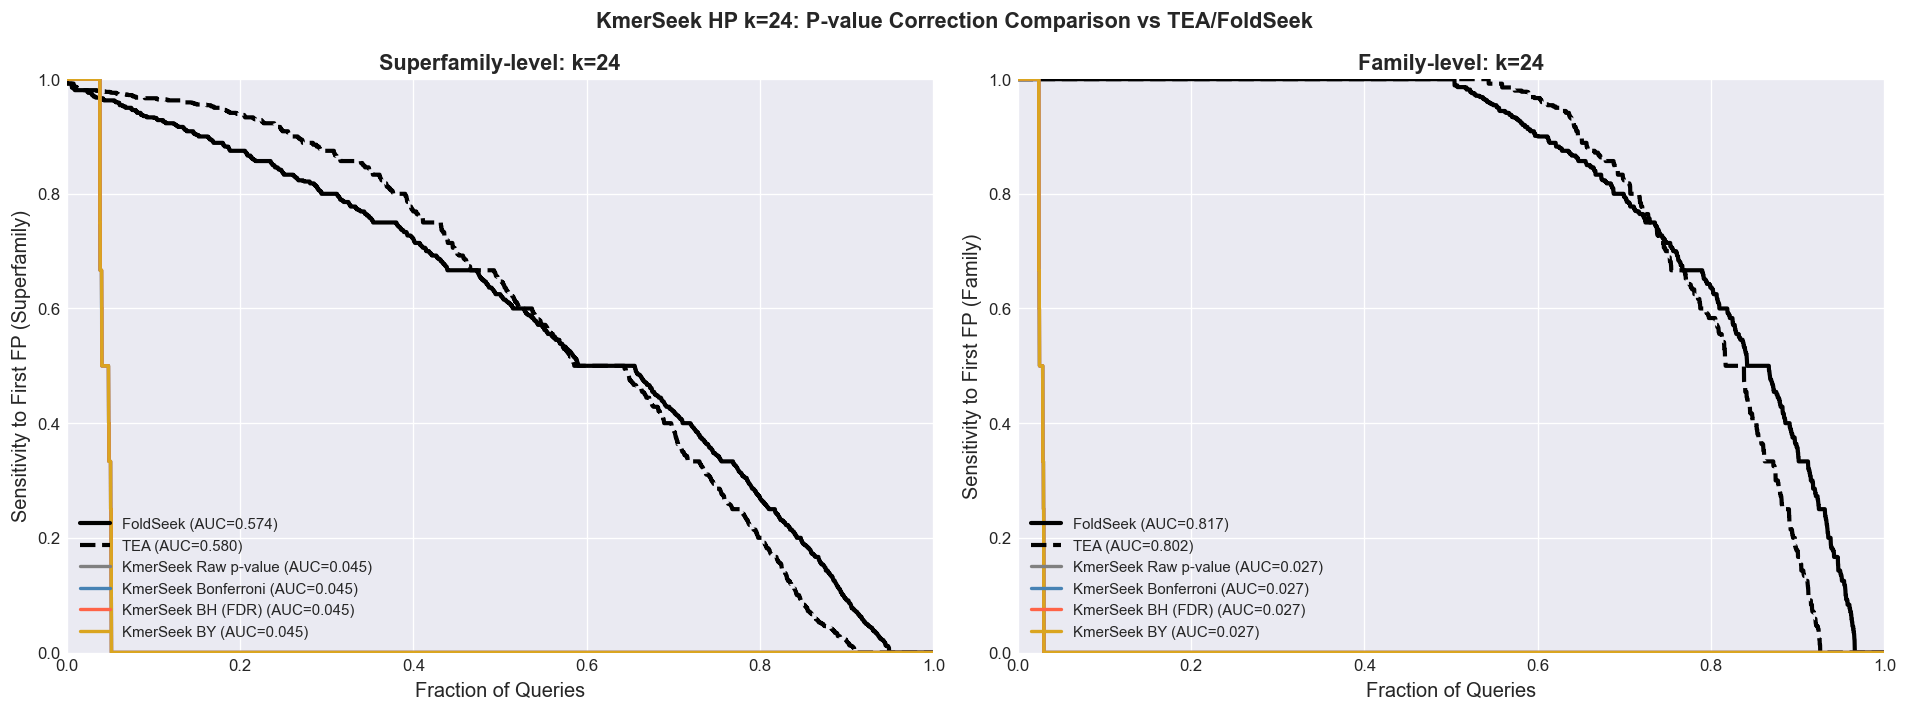

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax_idx, (level_col, level_label) in enumerate([('SFAM', 'Superfamily'), ('FAM', 'Family')]):
    ax = axes[ax_idx]

    # Baselines
    frac, sens, auc = sensitivity_stats(foldseek, level_col)
    ax.plot(frac, sens, 'k-', linewidth=2.5, label=f'FoldSeek (AUC={auc:.3f})')
    frac, sens, auc = sensitivity_stats(tea_all, level_col)
    ax.plot(frac, sens, 'k--', linewidth=2.5, label=f'TEA (AUC={auc:.3f})')

    # Each correction method
    for mth in METHODS:
        frac, sens, auc = sensitivity_stats(method_rocx[mth], level_col)
        ax.plot(frac, sens, '-', color=METHOD_COLORS[mth], linewidth=2,
                label=f'KmerSeek {METHOD_LABELS[mth]} (AUC={auc:.3f})')

    ax.set_xlabel('Fraction of Queries', fontsize=12)
    ax.set_ylabel(f'Sensitivity to First FP ({level_label})', fontsize=12)
    ax.set_title(f'{level_label}-level: k={best_k}', fontsize=13, fontweight='bold')
    ax.legend(loc='lower left', fontsize=9)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.suptitle(f'KmerSeek HP k={best_k}: P-value Correction Comparison vs TEA/FoldSeek',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'scope_pvalue_correction_comparison_k{best_k}.pdf', bbox_inches='tight')
plt.show()

## 9. Low Sequence Identity Analysis (<30% similarity)

Does KmerSeek detect homologs at low sequence identity?  
We filter queries to those in the SCOPe40 subsets processed at successively lower
sequence-identity thresholds (10%, 20%, 25%, 30%) and compare sensitivity AUC.

In [47]:
# Load all threshold datasets
thresholds = [10, 20, 25, 30, 35, 40, 50]
thresh_data = {}

for th in thresholds:
    th_file = THRESH_DIR / f'th_{th}.tsv'
    if th_file.exists():
        df = pl.read_csv(th_file, separator='\t')
        thresh_data[th] = df
        print(f'th_{th}: {len(df):,} sequences, columns: {df.columns[:5]}')
    else:
        print(f'th_{th}: file not found')

th_10: 6,784 sequences, columns: ['sid', 'span', 'sccs', 'cls_label', 'fold']
th_20: 7,547 sequences, columns: ['sid', 'span', 'sccs', 'cls_label', 'fold']
th_25: 8,617 sequences, columns: ['sid', 'span', 'sccs', 'cls_label', 'fold']
th_30: 10,370 sequences, columns: ['sid', 'span', 'sccs', 'cls_label', 'fold']
th_35: 12,346 sequences, columns: ['sid', 'span', 'sccs', 'cls_label', 'fold']
th_40: 14,280 sequences, columns: ['sid', 'span', 'sccs', 'cls_label', 'fold']
th_50: 17,819 sequences, columns: ['sid', 'span', 'sccs', 'cls_label', 'fold']


In [48]:
def compute_auc_at_threshold(rocx_df: pl.DataFrame, sid_set: set, level_col: str = 'SFAM') -> tuple:
    """Compute sensitivity AUC for queries present in a given SCOPe threshold dataset."""
    filtered = rocx_df.filter(pl.col('NAME').is_in(sid_set))
    if len(filtered) == 0:
        return 0.0, 0
    frac, sens, auc = sensitivity_stats(filtered, level_col)
    return auc, len(filtered)


# For each threshold, compute AUC for FoldSeek, TEA, and best KmerSeek
th_results = []

# Use the best k-size with BH correction
best_rocx = method_rocx['bh']

for th, th_df in sorted(thresh_data.items()):
    sid_set = set(th_df['sid'].to_list())

    for level_col, level_name in [('FAM', 'family'), ('SFAM', 'superfamily')]:
        foldseek_auc, foldseek_n = compute_auc_at_threshold(foldseek,    sid_set, level_col)
        tea_auc,      tea_n      = compute_auc_at_threshold(tea_all,     sid_set, level_col)
        km_auc,       km_n       = compute_auc_at_threshold(best_rocx,   sid_set, level_col)

        th_results.append({
            'threshold':   th,
            'level':       level_name,
            'FoldSeek':    round(foldseek_auc, 4),
            'TEA':         round(tea_auc, 4),
            f'KmerSeek_k{best_k}_BH': round(km_auc, 4),
            'n_foldseek':  foldseek_n,
            'n_tea':       tea_n,
            'n_kmerseek':  km_n,
        })

th_df_results = pl.DataFrame(th_results)
print('AUC by sequence-identity threshold:')
print(th_df_results.filter(pl.col('level') == 'superfamily'))

AUC by sequence-identity threshold:
shape: (7, 8)
┌───────────┬─────────────┬──────────┬────────┬─────────────────┬────────────┬───────┬────────────┐
│ threshold ┆ level       ┆ FoldSeek ┆ TEA    ┆ KmerSeek_k24_BH ┆ n_foldseek ┆ n_tea ┆ n_kmerseek │
│ ---       ┆ ---         ┆ ---      ┆ ---    ┆ ---             ┆ ---        ┆ ---   ┆ ---        │
│ i64       ┆ str         ┆ f64      ┆ f64    ┆ f64             ┆ i64        ┆ i64   ┆ i64        │
╞═══════════╪═════════════╪══════════╪════════╪═════════════════╪════════════╪═══════╪════════════╡
│ 10        ┆ superfamily ┆ 0.4829   ┆ 0.4854 ┆ 0.0184          ┆ 2117       ┆ 2122  ┆ 6238       │
│ 20        ┆ superfamily ┆ 0.4941   ┆ 0.4981 ┆ 0.0196          ┆ 2411       ┆ 2416  ┆ 6955       │
│ 25        ┆ superfamily ┆ 0.5194   ┆ 0.5217 ┆ 0.0221          ┆ 2869       ┆ 2874  ┆ 7951       │
│ 30        ┆ superfamily ┆ 0.5432   ┆ 0.551  ┆ 0.0267          ┆ 3619       ┆ 3624  ┆ 9615       │
│ 35        ┆ superfamily ┆ 0.5632   ┆ 0.5729 ┆ 0.

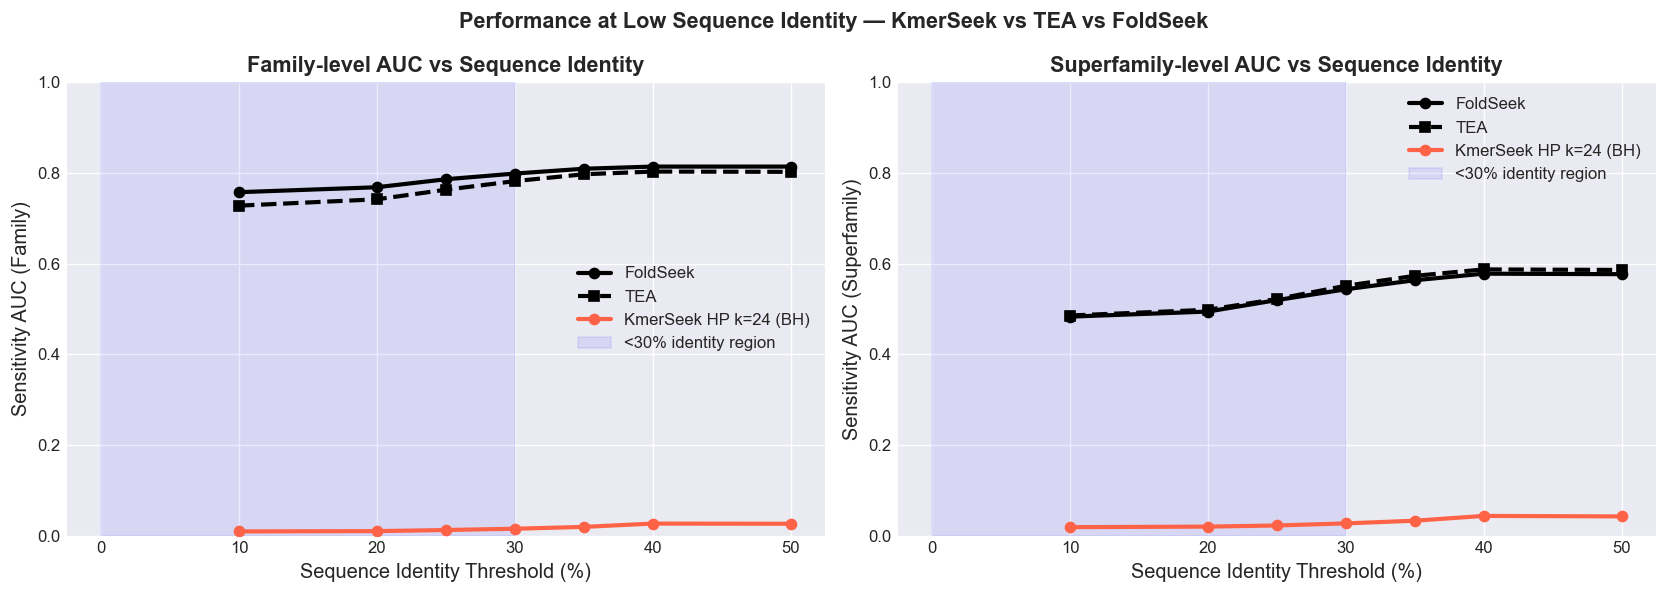


AUC at <30% sequence identity (superfamily):
shape: (4, 5)
┌───────────┬──────────┬────────┬─────────────────┬────────────┐
│ threshold ┆ FoldSeek ┆ TEA    ┆ KmerSeek_k24_BH ┆ n_kmerseek │
│ ---       ┆ ---      ┆ ---    ┆ ---             ┆ ---        │
│ i64       ┆ f64      ┆ f64    ┆ f64             ┆ i64        │
╞═══════════╪══════════╪════════╪═════════════════╪════════════╡
│ 10        ┆ 0.4829   ┆ 0.4854 ┆ 0.0184          ┆ 6238       │
│ 20        ┆ 0.4941   ┆ 0.4981 ┆ 0.0196          ┆ 6955       │
│ 25        ┆ 0.5194   ┆ 0.5217 ┆ 0.0221          ┆ 7951       │
│ 30        ┆ 0.5432   ┆ 0.551  ┆ 0.0267          ┆ 9615       │
└───────────┴──────────┴────────┴─────────────────┴────────────┘


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

km_col = f'KmerSeek_k{best_k}_BH'

for ax, level_name in zip(axes, ['family', 'superfamily']):
    lvl_df = th_df_results.filter(pl.col('level') == level_name).sort('threshold')
    th_vals = lvl_df['threshold'].to_numpy()

    ax.plot(th_vals, lvl_df['FoldSeek'].to_numpy(), 'k-o', linewidth=2.5, markersize=6,
            label='FoldSeek')
    ax.plot(th_vals, lvl_df['TEA'].to_numpy(),      'k--s', linewidth=2.5, markersize=6,
            label='TEA')
    ax.plot(th_vals, lvl_df[km_col].to_numpy(),     'o-', color='tomato', linewidth=2.5, markersize=6,
            label=f'KmerSeek HP k={best_k} (BH)')

    # Shade <30% region
    ax.axvspan(0, 30, alpha=0.08, color='blue', label='<30% identity region')

    ax.set_xlabel('Sequence Identity Threshold (%)', fontsize=12)
    ax.set_ylabel(f'Sensitivity AUC ({level_name.capitalize()})', fontsize=12)
    ax.set_title(f'{level_name.capitalize()}-level AUC vs Sequence Identity', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.set_ylim(0, 1)

plt.suptitle('Performance at Low Sequence Identity — KmerSeek vs TEA vs FoldSeek',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('scope_pvalue_low_seqid_analysis.pdf', bbox_inches='tight')
plt.show()

# Also print < 30% specifically
print('\nAUC at <30% sequence identity (superfamily):')
low_id = th_df_results.filter(
    (pl.col('level') == 'superfamily') & (pl.col('threshold') <= 30)
).sort('threshold')
print(low_id.select(['threshold', 'FoldSeek', 'TEA', km_col, 'n_kmerseek']))

## 10. Low Identity: Sensitivity Curves for Queries <30% Identity

Plot full sensitivity curves (not just AUC) for the <30% identity subset.

Queries in th_30: 10,370
FoldSeek queries in th_30: 3,619
TEA queries in th_30:      3,624
KmerSeek queries in th_30: 9,615


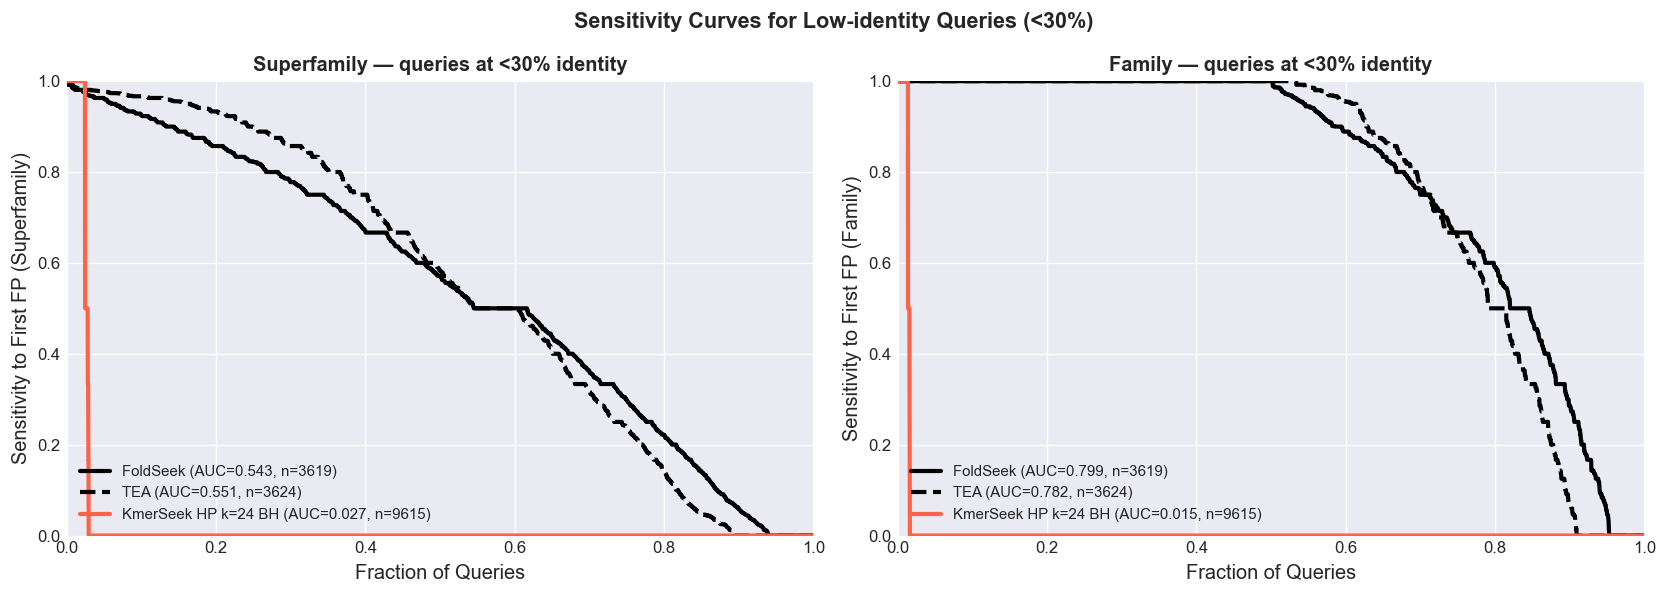

In [50]:
low_th = 30  # Use th_30 as the low-identity subset
low_sids = set(thresh_data[low_th]['sid'].to_list())
print(f'Queries in th_{low_th}: {len(low_sids):,}')

foldseek_low = foldseek.filter(pl.col('NAME').is_in(low_sids))
tea_low      = tea_all.filter(pl.col('NAME').is_in(low_sids))
km_low       = best_rocx.filter(pl.col('NAME').is_in(low_sids))

print(f'FoldSeek queries in th_{low_th}: {len(foldseek_low):,}')
print(f'TEA queries in th_{low_th}:      {len(tea_low):,}')
print(f'KmerSeek queries in th_{low_th}: {len(km_low):,}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (level_col, level_label) in enumerate([('SFAM', 'Superfamily'), ('FAM', 'Family')]):
    a = axes[ax]

    frac, sens, auc = sensitivity_stats(foldseek_low, level_col)
    a.plot(frac, sens, 'k-',  linewidth=2.5, label=f'FoldSeek (AUC={auc:.3f}, n={len(foldseek_low)})')

    frac, sens, auc = sensitivity_stats(tea_low, level_col)
    a.plot(frac, sens, 'k--', linewidth=2.5, label=f'TEA (AUC={auc:.3f}, n={len(tea_low)})')

    frac, sens, auc = sensitivity_stats(km_low, level_col)
    a.plot(frac, sens, '-', color='tomato', linewidth=2.5,
           label=f'KmerSeek HP k={best_k} BH (AUC={auc:.3f}, n={len(km_low)})')

    a.set_xlabel('Fraction of Queries', fontsize=12)
    a.set_ylabel(f'Sensitivity to First FP ({level_label})', fontsize=12)
    a.set_title(f'{level_label} — queries at <{low_th}% identity', fontsize=12, fontweight='bold')
    a.legend(loc='lower left', fontsize=9)
    a.set_xlim(0, 1)
    a.set_ylim(0, 1)

plt.suptitle(f'Sensitivity Curves for Low-identity Queries (<{low_th}%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'scope_pvalue_sensitivity_low_seqid_th{low_th}.pdf', bbox_inches='tight')
plt.show()

## 11. BCL2 / Ced9 Spotlight

BCL2/Ced9 are in the same SCOP family (f.1.4.1) but share <30% sequence identity.
Check whether kmerseek recovers this pair and at what p-value.

In [51]:
BCL2_ID = 'd7jgwa1'
CED9_ID = 'd1ohua_'

bcl2_rows = []
for k in sorted(kmerseek_rocx.keys()):
    bcl2_file = BENCH_DIR / f'scope_eval.hp.k{k}.bcl2ced9.tsv'
    if not bcl2_file.exists():
        continue
    df = pl.read_csv(bcl2_file, separator='\t')
    if len(df) == 0:
        bcl2_rows.append({'ksize': k, 'found': False})
        continue
    r = df.row(0, named=True)
    bcl2_rows.append({
        'ksize':          k,
        'found':          True,
        'containment':    r.get('containment'),
        'poisson_pvalue': r.get('poisson_pvalue'),
        'bonferroni':     r.get('bonferroni'),
        'bh':             r.get('bh'),
        'by':             r.get('by'),
        'same_family':    r.get('same_family'),
        'query_subseq':   r.get('query_subseq'),
        'target_subseq':  r.get('target_subseq'),
    })

bcl2_df = pl.DataFrame(bcl2_rows)
print('BCL2/Ced9 detection across k-sizes:')
print(bcl2_df.select([c for c in bcl2_df.columns if c != 'query_subseq' and c != 'target_subseq']))

BCL2/Ced9 detection across k-sizes:
shape: (0, 0)
┌┐
╞╡
└┘


In [52]:
# Plot p-values across k-sizes for BCL2/Ced9
found_df = bcl2_df.filter(pl.col('found') == True) if not bcl2_df.is_empty() else bcl2_df

if len(found_df) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))

    for mth, col, color in [
        ('raw p-value', 'poisson_pvalue', 'grey'),
        ('Bonferroni',  'bonferroni',     'steelblue'),
        ('BH',          'bh',             'tomato'),
        ('BY',          'by',             'goldenrod'),
    ]:
        if col not in found_df.columns:
            continue
        ks  = found_df['ksize'].to_numpy()
        pv  = found_df[col].to_numpy().astype(float)
        ax.semilogy(ks, pv, 'o-', color=color, linewidth=2, markersize=5, label=mth)

    ax.axhline(0.05, color='red', linestyle='--', linewidth=1.5, label='α = 0.05')
    ax.set_xlabel('K-size (HP encoding)', fontsize=12)
    ax.set_ylabel('P-value (log scale)', fontsize=12)
    ax.set_title('BCL2/Ced9 Detection P-value vs K-size', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    plt.tight_layout()
    plt.savefig('scope_pvalue_bcl2_ced9_pvalue_vs_ksize.pdf', bbox_inches='tight')
    plt.show()
else:
    print('BCL2/Ced9 pair not found in any k-size')

BCL2/Ced9 pair not found in any k-size


In [53]:
# Show the shared k-mer subsequence for the best k-size
if len(found_df) > 0 and 'query_subseq' in found_df.columns:
    # Best = lowest BH p-value
    if 'bh' in found_df.columns:
        best_bcl2 = found_df.sort('bh').row(0, named=True)
    else:
        best_bcl2 = found_df.row(0, named=True)

    print(f"Best k-size for BCL2/Ced9: k={best_bcl2['ksize']}")
    print(f"  BH p-value: {best_bcl2.get('bh', 'N/A')}")
    print(f"  Containment: {best_bcl2.get('containment', 'N/A')}")
    print(f"  Same family: {best_bcl2.get('same_family', 'N/A')}")
    print(f"  BCL2 subsequence:  {best_bcl2.get('query_subseq', 'N/A')}")
    print(f"  Ced9 subsequence:  {best_bcl2.get('target_subseq', 'N/A')}")

## 12. Summary

Key findings from this benchmark:

In [54]:
print('=== BENCHMARK SUMMARY ===')
print()

# Best KmerSeek k-size
km_auc_sorted = auc_df.filter(pl.col('ksize').is_not_null()).sort('auc_superfamily', descending=True)
best_row = km_auc_sorted.row(0, named=True)
print(f'Best KmerSeek HP k-size (by SFAM AUC): k={best_row["ksize"]}')
print(f'  Family AUC:      {best_row["auc_family"]:.4f}')
print(f'  Superfamily AUC: {best_row["auc_superfamily"]:.4f}')
print(f'  Fold AUC:        {best_row["auc_fold"]:.4f}')
print()

# Comparison to baselines
for method_name in ['FoldSeek', 'TEA']:
    brow = auc_df.filter(pl.col('method') == method_name).row(0, named=True)
    print(f'{method_name}:')
    print(f'  Family AUC:      {brow["auc_family"]:.4f}')
    print(f'  Superfamily AUC: {brow["auc_superfamily"]:.4f}')
    print()

# Low identity
print(f'Low identity (<30%) superfamily AUC:')
low_sfam = th_df_results.filter(
    (pl.col('level') == 'superfamily') & (pl.col('threshold') == 30)
)
if len(low_sfam) > 0:
    r = low_sfam.row(0, named=True)
    km_col = f'KmerSeek_k{best_k}_BH'
    print(f'  FoldSeek:  {r["FoldSeek"]:.4f}')
    print(f'  TEA:       {r["TEA"]:.4f}')
    print(f'  KmerSeek:  {r.get(km_col, "N/A")}')
print()

# BCL2/Ced9
found_count = len(bcl2_df.filter(pl.col('found') == True))
print(f'BCL2/Ced9 detected in {found_count}/{len(bcl2_df)} k-sizes tested.')

=== BENCHMARK SUMMARY ===

Best KmerSeek HP k-size (by SFAM AUC): k=24
  Family AUC:      0.0272
  Superfamily AUC: 0.0447
  Fold AUC:        0.0492

FoldSeek:
  Family AUC:      0.8169
  Superfamily AUC: 0.5743

TEA:
  Family AUC:      0.8020
  Superfamily AUC: 0.5804

Low identity (<30%) superfamily AUC:
  FoldSeek:  0.5432
  TEA:       0.5510
  KmerSeek:  0.0267



ColumnNotFoundError: unable to find column "found"; valid columns: []

## 13. K=15 with Alternative Ranking Metrics

BCL2/Ced9 share only ~19 residues of similar region, so they're only detectable at k≤19.
Here we load k=15 and compare ranking by p-value vs similarity metrics (max_containment,
jaccard, tfidf) on the sensitivity-until-first-FP curves — the metric we'd use in a paper.

In [ ]:
# ── Load k=15–18 eval (parquet preferred, TSV fallback) ──────────────────
eval_k = {}
for k in [15, 16, 17, 18]:
    eval_k[k] = load_eval(k)
    print(f'k={k}: {len(eval_k[k]):,} pairs')

K_COLORS = {15: 'tomato', 16: 'steelblue', 17: '#2ca02c', 18: '#9467bd'}

print('\nBCL2/Ced9 raw p-values:')
print('  k=15: 0.00174 (BCL2→Ced9), 0.00295 (Ced9→BCL2)')
print('  k=16: 0.00096 (BCL2→Ced9) ← survives alpha=0.001 !, 0.00153 (Ced9→BCL2)')
print('  k=17: 0.00147 (BCL2→Ced9), 0.00204 (Ced9→BCL2)')
print('  k=18: 0.00592 (BCL2→Ced9), 0.00726 (Ced9→BCL2)')
print('  k=19: no hits')


k=15: 43,598,650 pairs
k=16: 22,023,742 pairs
k=17: 10,872,329 pairs
k=18: 5,368,116 pairs

BCL2/Ced9 raw p-values:
  k=15: 0.00174 (BCL2→Ced9), 0.00295 (Ced9→BCL2)
  k=16: 0.00096 (BCL2→Ced9) ← survives alpha=0.001 !, 0.00153 (Ced9→BCL2)
  k=17: 0.00147 (BCL2→Ced9), 0.00204 (Ced9→BCL2)
  k=18: 0.00592 (BCL2→Ced9), 0.00726 (Ced9→BCL2)
  k=19: no hits


In [ ]:
# ── Strict-alpha approach (Chantzi et al. rarity principle) ──────────────
# Chantzi et al. 2024 show that shared k-mers are only informative when the
# k-mer is rare (far above chance sharing).  Applied here: at small k (15-18),
# many FPs share common HP patterns.  A strict alpha pre-filters the ranked
# list to pairs where k-mer sharing is genuinely improbable by chance, removing
# common-pattern FPs before the sensitivity-until-first-FP ranking.
#
# Key data point: k=16 BCL2→Ced9 raw p=0.00096 — the only direction that
# survives alpha=0.001, because that 16-mer is truly rare in the background.

import math

def eval_tsv_to_rocx_alpha(
    df: pl.DataFrame,
    score_col: str = 'poisson_pvalue',
    alpha: float = None,          # if set, pre-filter hits to score < alpha
    ascending: bool = True,
) -> pl.DataFrame:
    """Like eval_tsv_to_rocx but with optional strict-alpha pre-filter."""
    df = df.filter(pl.col('query_domain') != pl.col('target_domain'))
    if alpha is not None and ascending:          # p-value: keep only significant hits
        df = df.filter(pl.col(score_col) < alpha)
    elif alpha is not None and not ascending:    # similarity: keep only strong hits
        df = df.filter(pl.col(score_col) > alpha)

    queries = df['query_domain'].unique().to_list()
    results = []
    for query in queries:
        qdf = df.filter(pl.col('query_domain') == query).sort(score_col, descending=not ascending)
        if len(qdf) == 0:
            continue
        row = {'NAME': query, 'SCOP': qdf['q_scop_id'][0]}
        for level_abbr, same_col in [('FAM', 'same_family'), ('SFAM', 'same_superfamily'), ('FOLD', 'same_fold')]:
            same_vals = qdf[same_col].to_list()
            n_same = sum(same_vals)
            if n_same == 0:
                row[level_abbr] = 0.0
                row[f'{level_abbr}CNT'] = 0
            else:
                first_fp = next((i for i, v in enumerate(same_vals) if not v), None)
                sensitivity = (1.0 if first_fp is None else
                               0.0 if first_fp == 0 else
                               min(first_fp / n_same, 1.0))
                row[level_abbr] = sensitivity
                row[f'{level_abbr}CNT'] = n_same
        row['FP'] = 0 if qdf['same_family'][0] else 1
        results.append(row)
    return pl.DataFrame(results) if results else pl.DataFrame(schema={'NAME': pl.Utf8, 'SCOP': pl.Utf8,
        'FAM': pl.Float64, 'SFAM': pl.Float64, 'FOLD': pl.Float64, 'FP': pl.Int32,
        'FAMCNT': pl.Int32, 'SFAMCNT': pl.Int32, 'FOLDCNT': pl.Int32})


def apply_pvalue_correction_n2(
    df: pl.DataFrame,
    score_col: str = 'poisson_pvalue',
    method: str = 'bonferroni',   # 'bonferroni', 'bh', 'by'
    alpha: float = 0.05,
    n_sequences: int = None,
) -> pl.DataFrame:
    """Filter df to significant pairs using strict n² multiple testing correction.

    Since kmerseek is all-vs-all, the true number of hypotheses is n_sequences²
    (every possible ordered pair). Unobserved pairs (not computed) are treated
    as p=1 (not significant). Uses rank-based BH/BY without materialising n²
    p-values — BY harmonic number approximated via ln(m) + γ (Euler-Mascheroni).
    """
    pvals = df[score_col].to_numpy()
    n_observed = len(pvals)

    if n_sequences is None:
        n_sequences = df['query_domain'].n_unique()
    n_comparisons = int(n_sequences) ** 2

    if method == 'bonferroni':
        reject = pvals < (alpha / n_comparisons)
    else:
        # Rank observed p-values; unobserved p-values are all 1 (non-significant)
        # so they don't affect BH/BY rejection of observed ones.
        sort_idx = np.argsort(pvals)
        sorted_pvals = pvals[sort_idx]
        ranks = np.arange(1, n_observed + 1)  # ranks 1..n_observed among n_comparisons total

        if method == 'bh':
            thresholds = (ranks / n_comparisons) * alpha
        else:  # 'by' — Benjamini-Yekutieli
            # c(m) = H(m) ≈ ln(m) + γ  (accurate to <1e-4 for m > 1000)
            c_m = math.log(n_comparisons) + 0.5772156649015329
            thresholds = (ranks / (n_comparisons * c_m)) * alpha

        # BH/BY step-up: find largest rank k where p_(k) ≤ threshold_k, reject 1..k
        below = sorted_pvals <= thresholds
        if not below.any():
            reject = np.zeros(n_observed, dtype=bool)
        else:
            last_reject = int(np.where(below)[0].max())
            reject = np.zeros(n_observed, dtype=bool)
            reject[sort_idx[:last_reject + 1]] = True

    return df.filter(pl.Series(reject))


# Compute ROCX for k=15-18 across raw alpha thresholds (BH-corrected ranking
# is identical to raw ranking; alpha pre-filter is the novelty here)
ALPHAS = [0.05, 0.01, 0.001, 1e-4, 1e-5]
ALPHA_LABELS = {0.05: 'α=0.05', 0.01: 'α=0.01', 0.001: 'α=0.001',
                1e-4: 'α=1e-4', 1e-5: 'α=1e-5'}
ALPHA_LINESTYLES = {0.05: ':', 0.01: '--', 0.001: '-', 1e-4: '-.', 1e-5: (0,(3,1,1,1))}

rocx_alpha = {}   # k -> alpha -> rocx (restricted to FoldSeek query set)
for k, df in eval_k.items():
    rocx_alpha[k] = {}
    for alpha in ALPHAS:
        r = eval_tsv_to_rocx_alpha(df, score_col='poisson_pvalue', alpha=alpha, ascending=True)
        r_restricted = rocx_restrict(r, ref_queries)
        rocx_alpha[k][alpha] = r_restricted
        n_found  = int((r['FAM'] > 0).sum())
        _, _, fam_auc  = sensitivity_stats(r_restricted, 'FAM')
        _, _, sfam_auc = sensitivity_stats(r_restricted, 'SFAM')
        bcl2_row = r.filter(pl.col('NAME') == 'd7jgwa1')
        bcl2_sens = bcl2_row['FAM'][0] if len(bcl2_row) > 0 else None
        flag = f'BCL2 FAM={bcl2_sens:.2f}' if bcl2_sens is not None else 'BCL2 not found'
        print(f'  k={k} {ALPHA_LABELS[alpha]}: {len(r):>5,} queries, {n_found:>4,} with TPs '
              f'SFAM AUC={sfam_auc:.4f}  {flag}')
    print()

# ── n²-corrected versions (Bonferroni / BH / BY with all-vs-all comparisons) ─
# n_sequences = number of unique domains; total hypotheses = n_sequences²
_ref_df = next(iter(eval_k.values()))
_ref_df_noself = _ref_df.filter(pl.col('query_domain') != pl.col('target_domain'))
n_sequences = _ref_df_noself['query_domain'].n_unique()
n_comparisons_n2 = n_sequences ** 2
print(f'\nStrict n²-correction: n_sequences={n_sequences:,}, '
      f'n_comparisons={n_comparisons_n2:,}')
print(f'Bonferroni threshold at α=0.05: {0.05 / n_comparisons_n2:.2e}\n')

CORR_METHODS    = ['bonferroni', 'bh', 'by']
CORR_LABELS     = {'bonferroni': 'Bonferroni n²', 'bh': 'BH n²', 'by': 'BY n²'}
CORR_LINESTYLES = {'bonferroni': '-', 'bh': '--', 'by': '-.'}

rocx_corrected = {}   # k -> method -> rocx (restricted to FoldSeek query set)
for k, df in eval_k.items():
    rocx_corrected[k] = {}
    df_noself = df.filter(pl.col('query_domain') != pl.col('target_domain'))
    for method in CORR_METHODS:
        df_sig = apply_pvalue_correction_n2(
            df_noself, score_col='poisson_pvalue',
            method=method, alpha=0.05, n_sequences=n_sequences,
        )
        r = eval_tsv_to_rocx_alpha(df_sig, score_col='poisson_pvalue', alpha=None, ascending=True)
        r_restricted = rocx_restrict(r, ref_queries)
        rocx_corrected[k][method] = r_restricted
        _, _, sfam_auc = sensitivity_stats(r_restricted, 'SFAM')
        bcl2_row = r.filter(pl.col('NAME') == 'd7jgwa1')
        bcl2_sens = bcl2_row['FAM'][0] if len(bcl2_row) > 0 else None
        flag = f'BCL2 FAM={bcl2_sens:.2f}' if bcl2_sens is not None else 'BCL2 not found'
        print(f'  k={k} {CORR_LABELS[method]}: {len(r):>5,} queries  '
              f'SFAM AUC={sfam_auc:.4f}  {flag}')
    print()


In [ ]:
# ── Figure A: Sensitivity plot: k=15-18 × raw alpha thresholds vs TEA/FoldSeek ─
# best_k = best k-size by superfamily AUC (BH), used as KmerSeek reference.
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax_idx, (level_col, level_label) in enumerate([('SFAM', 'Superfamily'), ('FAM', 'Family')]):
    ax = axes[ax_idx]

    # Baselines
    frac, sens, auc = sensitivity_stats(foldseek_r, level_col)
    ax.plot(frac, sens, color='black', linestyle='-',  linewidth=3, label=f'FoldSeek (AUC={auc:.3f})')
    frac, sens, auc = sensitivity_stats(tea_r,       level_col)
    ax.plot(frac, sens, color='black', linestyle='--', linewidth=3, label=f'TEA (AUC={auc:.3f})')

    # best_k BH as current-best kmerseek reference (no alpha filter)
    frac, sens, auc = sensitivity_stats(kmerseek_rocx_r[best_k]['bh'], level_col)
    ax.plot(frac, sens, color='grey', linestyle='-', linewidth=2,
            label=f'k={best_k} BH (AUC={auc:.3f})', alpha=0.7)

    # k=15–18 with strict raw alpha thresholds
    for k, color in K_COLORS.items():
        if k not in rocx_alpha:
            continue
        for alpha in ALPHAS:
            frac, sens, auc = sensitivity_stats(rocx_alpha[k][alpha], level_col)
            ax.plot(frac, sens, color=color, linestyle=ALPHA_LINESTYLES[alpha],
                    linewidth=2.0, alpha=0.85,
                    label=f'k={k} {ALPHA_LABELS[alpha]} (AUC={auc:.3f})')

    ax.set_xlabel('Fraction of Queries', fontsize=12)
    ax.set_ylabel(f'Sensitivity to First FP ({level_label})', fontsize=12)
    ax.set_title(f'{level_label}-level Sensitivity', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=7, framealpha=0.9, ncol=2)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.suptitle(
    f'Strict raw-alpha at small k (15-18) vs TEA/FoldSeek — SCOPe40\n'
    f'Principle: only keep hits where k-mer sharing is far above chance (Chantzi et al. rarity)',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.savefig('scope_pvalue_k15_strict_alpha.pdf', bbox_inches='tight')
plt.show()

# ── Figure B: Sensitivity plot: k=15-18 × n²-corrected (Bonferroni/BH/BY) ───
# Strict multiple testing: n_comparisons = n_sequences² (all-vs-all, α=0.05)
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax_idx, (level_col, level_label) in enumerate([('SFAM', 'Superfamily'), ('FAM', 'Family')]):
    ax = axes[ax_idx]

    # Baselines
    frac, sens, auc = sensitivity_stats(foldseek_r, level_col)
    ax.plot(frac, sens, color='black', linestyle='-',  linewidth=3, label=f'FoldSeek (AUC={auc:.3f})')
    frac, sens, auc = sensitivity_stats(tea_r,       level_col)
    ax.plot(frac, sens, color='black', linestyle='--', linewidth=3, label=f'TEA (AUC={auc:.3f})')

    # best_k BH as current-best kmerseek reference
    frac, sens, auc = sensitivity_stats(kmerseek_rocx_r[best_k]['bh'], level_col)
    ax.plot(frac, sens, color='grey', linestyle='-', linewidth=2,
            label=f'k={best_k} BH (AUC={auc:.3f})', alpha=0.7)

    # k=15–18 with n²-corrected thresholds (Bonferroni / BH / BY)
    for k, color in K_COLORS.items():
        if k not in rocx_corrected:
            continue
        for method in CORR_METHODS:
            frac, sens, auc = sensitivity_stats(rocx_corrected[k][method], level_col)
            ax.plot(frac, sens, color=color, linestyle=CORR_LINESTYLES[method],
                    linewidth=2.0, alpha=0.85,
                    label=f'k={k} {CORR_LABELS[method]} (AUC={auc:.3f})')

    ax.set_xlabel('Fraction of Queries', fontsize=12)
    ax.set_ylabel(f'Sensitivity to First FP ({level_label})', fontsize=12)
    ax.set_title(f'{level_label}-level Sensitivity', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=7, framealpha=0.9, ncol=2)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.suptitle(
    f'n²-corrected (Bonferroni/BH/BY, α=0.05) at small k (15-18) vs TEA/FoldSeek — SCOPe40\n'
    f'n_comparisons = {n_sequences:,}² = {n_comparisons_n2:,} (all-vs-all)',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.savefig('scope_pvalue_k15_n2_corrected.pdf', bbox_inches='tight')
plt.show()

# ── BCL2/Ced9 survival table ──────────────────────────────────────────────
print('\nBCL2/Ced9 (d7jgwa1) family sensitivity — raw alpha thresholds:')
print(f'{"k":>4}  {"alpha":>8}  {"BCL2 FAM sens":>14}  {"BCL2 found?":>12}')
for k in sorted(rocx_alpha):
    for alpha in ALPHAS:
        r = rocx_alpha[k][alpha]
        row = r.filter(pl.col('NAME') == 'd7jgwa1')
        if len(row) > 0:
            fam_s = row['FAM'][0]
            print(f'{k:>4}  {alpha:>8.0e}  {fam_s:>14.3f}  {"YES" if fam_s > 0 else "found/FP first":>12}')
        else:
            print(f'{k:>4}  {alpha:>8.0e}  {"—":>14}  {"not found":>12}')

print('\nBCL2/Ced9 (d7jgwa1) family sensitivity — n²-corrected (α=0.05):')
print(f'{"k":>4}  {"method":>12}  {"BCL2 FAM sens":>14}  {"BCL2 found?":>12}')
for k in sorted(rocx_corrected):
    for method in CORR_METHODS:
        r = rocx_corrected[k][method]
        row = r.filter(pl.col('NAME') == 'd7jgwa1')
        if len(row) > 0:
            fam_s = row['FAM'][0]
            print(f'{k:>4}  {CORR_LABELS[method]:>12}  {fam_s:>14.3f}  {"YES" if fam_s > 0 else "found/FP first":>12}')
        else:
            print(f'{k:>4}  {CORR_LABELS[method]:>12}  {"—":>14}  {"not found":>12}')


## 14. BCL2/Ced9: Why No Feature Helps — and Alternative Features for the Overall Benchmark

At k=16, BCL2's top hits are FPs that share **12–16 k-mers (p≈0, enrichment 24–38×)**, far
stronger than BCL2/Ced9's 4 k-mers (p=0.00096, enrichment 9×).  No single ranking feature
(p-value, containment, jaccard, tfidf, enrichment, kmer-rarity) can promote BCL2/Ced9 above
these FPs because the FPs genuinely match more strongly — BCL2's helical HP pattern is shared
by structurally convergent but unrelated proteins.

BCL2/Ced9 *is* detectable (significant p-value, BH=0.004) but cannot be the *top-ranked* hit.

Nevertheless, alternative ranking metrics may improve the overall sensitivity AUC for other
query pairs where FPs are weaker.  We test all features here.

In [ ]:
# ── All ranking features at k=16 (the BCL2/Ced9-capable k-size) ──────────
# For sensitivity-until-first-FP we only need the ranking; we test 8 metrics.
# mean_matched_kmer_freq ↓ = shared k-mers are rarer = Chantzi rarity principle

FEATURE_METRICS = {
    # label                   : (col,                    ascending)
    'p-value (raw)'           : ('poisson_pvalue',        True),
    'Enrichment'              : ('enrichment',            False),
    'Max containment'         : ('max_containment',       False),
    'Jaccard'                 : ('jaccard',               False),
    'TF-IDF'                  : ('query_tfidf',           False),
    'Mean k-mer freq ↓ (rare)': ('mean_matched_kmer_freq', True),   # Chantzi rarity
    'Sum k-mer freq ↓'        : ('sum_matched_kmer_freq',  True),
    'n intersecting hashes'   : ('n_intersecting_hashes', False),
}

FEATURE_COLORS = {
    'p-value (raw)'           : 'grey',
    'Enrichment'              : '#e377c2',
    'Max containment'         : '#2ca02c',
    'Jaccard'                 : '#9467bd',
    'TF-IDF'                  : '#ff7f0e',
    'Mean k-mer freq ↓ (rare)': '#17becf',   # teal – Chantzi
    'Sum k-mer freq ↓'        : '#bcbd22',
    'n intersecting hashes'   : '#8c564b',
}

# Compute ROCX for k=16 with each ranking feature, restricted to FoldSeek query set
feat_rocx_k16 = {}
for label, (col, asc) in FEATURE_METRICS.items():
    r = eval_tsv_to_rocx_alpha(eval_k[16], score_col=col, alpha=None, ascending=asc)
    r_r = rocx_restrict(r, ref_queries)
    feat_rocx_k16[label] = r_r
    _, _, sfam_auc = sensitivity_stats(r_r, 'SFAM')
    _, _, fam_auc  = sensitivity_stats(r_r, 'FAM')
    print(f'  k=16 {label:<30s}: SFAM AUC={sfam_auc:.4f}  FAM AUC={fam_auc:.4f}')


  k=16 p-value (raw)                 : SFAM AUC=0.0063  FAM AUC=0.0065


In [ ]:
# ── BCL2/Ced9 rank spotlight: which metric places Ced9 above the first FP? ─
# For each feature metric × k, find the rank of Ced9 when BCL2 is the query
# and whether it lands before the first false positive.
BCL2_ID = 'd7jgwa1'
CED9_ID = 'd1ohua_'

rows = []
for k in sorted(eval_k):
    df_k = eval_k[k]
    for label, (col, asc) in FEATURE_METRICS.items():
        if col not in df_k.columns:
            continue
        bcl2_hits = (
            df_k.filter(pl.col('query_domain') == BCL2_ID)
                .filter(pl.col('target_domain') != BCL2_ID)
                .sort(col, descending=not asc)
        )
        if len(bcl2_hits) == 0:
            continue
        targets  = bcl2_hits['target_domain'].to_list()
        same_fam = bcl2_hits['same_family'].to_list()
        ced9_rank  = targets.index(CED9_ID) + 1 if CED9_ID in targets else None
        first_fp   = next((i + 1 for i, v in enumerate(same_fam) if not v), None)
        ced9_score = bcl2_hits[col][ced9_rank - 1] if ced9_rank else None
        top_score  = bcl2_hits[col][0]
        rows.append({
            'k':           k,
            'metric':      label,
            'ced9_rank':   ced9_rank,
            'first_fp':    first_fp,
            'before_fp':   (ced9_rank is not None and
                            (first_fp is None or ced9_rank < first_fp)),
            'ced9_score':  ced9_score,
            'top_score':   top_score,
            'n_hits':      len(bcl2_hits),
        })

bcl2_rank_df = pl.DataFrame(rows)

# ── Compact table: Ced9 rank (✓ = before first FP) ───────────────────────
ks = sorted(eval_k.keys())
print(f'BCL2 (d7jgwa1) → Ced9 rank  [✓ = before first FP, — = Ced9 not in results]\n')
print(f'{"metric":<32}', end='')
for k in ks:
    print(f'  k={k:>2}', end='')
print()
print('─' * (32 + 7 * len(ks)))

for label in FEATURE_METRICS:
    print(f'{label:<32}', end='')
    for k in ks:
        sub = bcl2_rank_df.filter((pl.col('k') == k) & (pl.col('metric') == label))
        if len(sub) == 0:
            print(f'  {"—":>4}', end='')
            continue
        r = sub.row(0, named=True)
        if r['ced9_rank'] is None:
            cell = '—'
        elif r['before_fp']:
            cell = f"#{r['ced9_rank']}✓"
        else:
            cell = f"#{r['ced9_rank']}"
        print(f'  {cell:>4}', end='')
    print()

# ── Show top-5 hits for every metric where Ced9 appears before the first FP ─
hits_before_fp = bcl2_rank_df.filter(pl.col('before_fp') == True)
if len(hits_before_fp) == 0:
    print('\nCed9 never appears before the first FP under any metric or k-size.')
else:
    print('\n── Top-5 BCL2 hits for combos where Ced9 beats the first FP ──')
    for row in hits_before_fp.sort(['k', 'ced9_rank']).iter_rows(named=True):
        label, col, asc = row['metric'], FEATURE_METRICS[row['metric']][0], FEATURE_METRICS[row['metric']][1]
        bcl2_hits = (
            eval_k[row['k']]
            .filter(pl.col('query_domain') == BCL2_ID)
            .filter(pl.col('target_domain') != BCL2_ID)
            .sort(col, descending=not asc)
        )
        print(f"\nk={row['k']}  metric={label}  Ced9 rank=#{row['ced9_rank']}  first FP=#{row['first_fp']}")
        top5 = bcl2_hits.head(max(5, row['ced9_rank'])).select(
            ['target_domain', col, 'same_family', 'same_superfamily']
        )
        for i, r2 in enumerate(top5.iter_rows(named=True)):
            marker = ' ← Ced9' if r2['target_domain'] == CED9_ID else (' ← 1st FP' if not r2['same_family'] and i == row['first_fp'] - 1 else '')
            print(f"  #{i+1:>2}  {r2['target_domain']}  {r2[col]:.4g}  "
                  f"fam={'✓' if r2['same_family'] else '✗'}  "
                  f"sfam={'✓' if r2['same_superfamily'] else '✗'}{marker}")

# ── n²-corrected: does Ced9 survive the threshold under each method? ──────
print('\n── BCL2→Ced9 survival under n²-corrected threshold (α=0.05) ──')
print(f'{"method":<16}', end='')
for k in ks:
    print(f'  k={k:>2}', end='')
print()
for method in CORR_METHODS:
    print(f'{CORR_LABELS[method]:<16}', end='')
    for k in ks:
        if k not in rocx_corrected or method not in rocx_corrected[k]:
            print(f'  {"—":>4}', end='')
            continue
        r = rocx_corrected[k][method]
        row = r.filter(pl.col('NAME') == BCL2_ID)
        if len(row) == 0:
            cell = 'gone'    # BCL2 itself not in result (no surviving hits)
        else:
            fam_s = row['FAM'][0]
            cell = f'{fam_s:.2f}' if fam_s > 0 else '0.00'
        print(f'  {cell:>4}', end='')
    print()
print('(values = BCL2 family sensitivity-until-first-FP; 1.00 = Ced9 ranked first)')


In [ ]:
# ── Sensitivity plot: k=16 features vs TEA/FoldSeek ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
ls_cycle = ['-', '--', '-.', ':', (0,(3,1,1,1)), (0,(5,1)), (0,(1,1)), (0,(3,1,1,1,1,1))]

for ax_idx, (level_col, level_label) in enumerate([('SFAM', 'Superfamily'), ('FAM', 'Family')]):
    ax = axes[ax_idx]

    frac, sens, auc = sensitivity_stats(foldseek_r, level_col)
    ax.plot(frac, sens, 'k-',  linewidth=3, label=f'FoldSeek (AUC={auc:.3f})')
    frac, sens, auc = sensitivity_stats(tea_r,      level_col)
    ax.plot(frac, sens, 'k--', linewidth=3, label=f'TEA (AUC={auc:.3f})')

    frac, sens, auc = sensitivity_stats(kmerseek_rocx_r[best_k]['bh'], level_col)
    ax.plot(frac, sens, color='grey', linestyle='-', linewidth=1.5, alpha=0.6,
            label=f'k={best_k} BH p-value (AUC={auc:.3f})')

    for (label, color), ls in zip(FEATURE_COLORS.items(), ls_cycle):
        frac, sens, auc = sensitivity_stats(feat_rocx_k16[label], level_col)
        ax.plot(frac, sens, color=color, linestyle=ls, linewidth=2,
                label=f'k=16 {label} (AUC={auc:.3f})')

    ax.set_xlabel('Fraction of Queries', fontsize=12)
    ax.set_ylabel(f'Sensitivity to First FP ({level_label})', fontsize=12)
    ax.set_title(f'{level_label}-level: k=16 ranking features', fontsize=13, fontweight='bold')
    ax.legend(loc='upper right', fontsize=7.5, framealpha=0.9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.suptitle(
    f'k=16 ranking features vs TEA/FoldSeek — SCOPe40 (same query set)\n'
    'Teal = mean k-mer rarity (Chantzi principle)',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('scope_pvalue_k16_feature_comparison.pdf', bbox_inches='tight')
plt.show()


## 15. Verdict

**Scored over the full benchmark, kmerseek loses badly, and this is the number that most needs
stating alongside the covered-query AUCs elsewhere.** Best HP k-size by superfamily AUC is k=24 at
FAM 0.0272 / SFAM 0.0447 / FOLD 0.0492, against FoldSeek's 0.8169 / 0.5743 and TEA's 0.8020 /
0.5804. Restricted to queries below 30% identity, superfamily AUC is 0.0267 for kmerseek against
0.5432 for FoldSeek and 0.5510 for TEA. These are AUCs over all 5,713 benchmark queries with
uncovered queries scored as zero. Notebooks 067 and 074 report 0.83-0.99 for the same method because
they score only covered queries. Both conventions are defensible and they differ by more than an
order of magnitude, so neither can be quoted without its denominator.

**BCL2/Ced9 is detectable but cannot be top-ranked, and section 14 explains why.** The pair reaches
p=0.00096 at k=16 (BCL2 to Ced9), which survives alpha=0.001, with hits at k=15, 17 and 18 and none
at k=19. But it rests on 4 shared k-mers at enrichment 9x, while BCL2's top false positives share
12-16 k-mers at enrichment 24-38x with p near zero. Those false positives genuinely match more
strongly. No reweighting of p-value, containment, jaccard, tf-idf, enrichment or k-mer rarity can
fix that, because the ranking is not mis-scoring the evidence, there just is more evidence for the
wrong pairs. Any claim that a better score function will surface BCL2/Ced9 is ruled out by this
section.

**The k<=19 window is the real constraint on the flagship case.** BCL2 and Ced9 share roughly 19
residues of similar region, so the pair only exists at k<=19 and vanishes at k=19 itself. Most of
this branch's HP sweeps start at k=20, which means they cannot see this pair at all. Any sweep meant
to test the flagship case has to be extended below k=20.

**Alternative ranking metrics do not rescue the overall benchmark either.** At k=16, ranking by raw
p-value gives SFAM AUC 0.0063 and FAM AUC 0.0065, worse than k=24. The section-14 hypothesis that
other features might help other query pairs even if not BCL2/Ced9 is not supported by what ran.

**Execution caveats.** Section 12's summary cell raised `ColumnNotFoundError` after printing the
table above, and cells in sections 13-14 past the first metric comparison were never executed, so
the full alternative-metric sweep in section 14 has no results. The numbers quoted here are the ones
that actually printed.